In [1]:
#Connexion de Python à MySQL avec SQLAlchemy (Connexion de Python à MySQL avec SQLAlchemy)
%pip install sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sqlalchemy import create_engine

In [3]:
import mysql.connector

In [4]:
print("Connexion MySQL prête")

Connexion MySQL prête


In [5]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sofyanobayd1234@",
    database="banking_analysis"
)

print("Connexion réussie")

Connexion réussie


In [6]:
#Créer la connexion SQLAlchemy
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="Sofyanobayd1234@",
    host="localhost",
    port=3306,
    database="banking_analysis"
)

engine = create_engine(url)

print("Engine créé avec succès")

Engine créé avec succès


In [7]:
#ester la connexion
with engine.connect() as connection:
    print("Connexion SQLAlchemy réussie")

Connexion SQLAlchemy réussie


In [8]:
#Importer Pandas
import pandas as pd

query = "SELECT * FROM bank_clients"

df = pd.read_sql(query, engine)

df.head()

,id,edad,genero,nivel_educativo,region,ingreso_mensual,saldo_cuenta,score_crediticio,dias_mora_12m,monto_prestamo_solicitado
0,1,56,M,Secundaria,Norte,3390.29,7044.24,630,5,8575.03
1,4,32,F,Universitario,Norte,2951.14,6405.47,591,4,9040.18
2,5,60,F,Postgrado,Sur,3701.95,7720.67,641,8,12337.47
3,6,25,M,Secundaria,Centro,1419.09,1028.84,461,7,6198.48
4,7,38,F,Tecnico,Centro,2471.13,5243.97,551,11,4004.28


In [9]:
# vérifier les données importées
df.shape

(6646, 10)

In [10]:
# noms colonnes
df.columns

Index(['id', 'edad', 'genero', 'nivel_educativo', 'region', 'ingreso_mensual',
       'saldo_cuenta', 'score_crediticio', 'dias_mora_12m',
       'monto_prestamo_solicitado'],
      dtype='object')

In [11]:
# info dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6646 entries, 0 to 6645
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         6646 non-null   int64  
 1   edad                       6646 non-null   int64  
 2   genero                     6646 non-null   object 
 3   nivel_educativo            6646 non-null   object 
 4   region                     6646 non-null   object 
 5   ingreso_mensual            6646 non-null   float64
 6   saldo_cuenta               6646 non-null   float64
 7   score_crediticio           6646 non-null   int64  
 8   dias_mora_12m              6646 non-null   int64  
 9   monto_prestamo_solicitado  6646 non-null   float64
dtypes: float64(3), int64(4), object(3)
memory usage: 519.3+ KB


In [12]:
df.describe()

,id,edad,ingreso_mensual,saldo_cuenta,score_crediticio,dias_mora_12m,monto_prestamo_solicitado
count,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000
mean,4999.267981,46.962985,2160.593300,3890.906837,582.944929,7.156937,6696.139029
std,2879.065817,16.639202,1225.182186,2342.823325,77.876542,2.732391,4901.853111
min,1.000000,18.000000,299.310000,0.000000,312.000000,0.000000,500.000000
25%,2498.250000,33.000000,1332.952500,2307.850000,530.000000,5.000000,3412.725000
50%,4983.500000,47.000000,1872.115000,3464.315000,582.000000,7.000000,5632.095000
75%,7463.750000,62.000000,2670.207500,4929.245000,637.000000,9.000000,8590.472500
max,9999.000000,75.000000,12945.840000,22405.950000,826.000000,19.000000,48432.720000


In [13]:
df.tail()

,id,edad,genero,nivel_educativo,region,ingreso_mensual,saldo_cuenta,score_crediticio,dias_mora_12m,monto_prestamo_solicitado
6641,9992,48,M,Tecnico,Centro,1436.09,3560.77,607,8,5215.52
6642,9993,27,M,Secundaria,Norte,1956.50,2770.93,538,7,3621.13
6643,9997,61,F,Universitario,Norte,4606.28,8374.05,695,3,17278.07
6644,9998,35,F,Universitario,Norte,2511.50,5458.03,614,8,9436.42
6645,9999,40,M,Universitario,Oriente,3722.77,6223.47,703,4,14250.79


In [14]:
# les valeures manquantes
df.isnull().sum()

id                           0
edad                         0
genero                       0
nivel_educativo              0
region                       0
ingreso_mensual              0
saldo_cuenta                 0
score_crediticio             0
dias_mora_12m                0
monto_prestamo_solicitado    0
dtype: int64

In [15]:
#doublons
df.duplicated().sum()

np.int64(0)

In [16]:
#Vérifier les types de données
df.dtypes

id                             int64
edad                           int64
genero                        object
nivel_educativo               object
region                        object
ingreso_mensual              float64
saldo_cuenta                 float64
score_crediticio               int64
dias_mora_12m                  int64
monto_prestamo_solicitado    float64
dtype: object

In [17]:
#Vérifier les valeurs uniques des variables catégorielles
print("Genre :", df["genero"].unique())
print("Niveau éducatif :", df["nivel_educativo"].unique())
print("Région :", df["region"].unique())

Genre : ['M' 'F']
Niveau éducatif : ['Secundaria' 'Universitario' 'Postgrado' 'Tecnico' 'Primaria']
Région : ['Norte' 'Sur' 'Centro' 'Occidente' 'Oriente' '']


In [18]:
#Compter les modalités de chaque variable catégorielle
print("Genre")
print(df["genero"].value_counts(dropna=False))

print("\nNiveau éducatif")
print(df["nivel_educativo"].value_counts(dropna=False))

print("\nRégion")
print(df["region"].value_counts(dropna=False))

Genre
genero
M    3392
F    3254
Name: count, dtype: int64

Niveau éducatif
nivel_educativo
Secundaria       2195
Universitario    1610
Tecnico          1373
Primaria          979
Postgrado         489
Name: count, dtype: int64

Région
region
Centro       1786
Norte        1393
Sur          1329
Oriente      1041
Occidente     905
              192
Name: count, dtype: int64


In [19]:
#Vérifier les valeurs manquantes réelles
df["region"].isnull().sum()

np.int64(0)

In [20]:
#Vérifier les valeurs vides
(df["region"].str.strip() == "").sum()

np.int64(192)

In [21]:
#Remplacer les valeurs vides par des valeurs manquantes
import numpy as np

df["region"] = df["region"].replace(r"^\s*$", np.nan, regex=True)

In [22]:
# exucution
df["region"].isnull().sum()

np.int64(192)

In [23]:
#Traiter les valeurs manquantes de la région
df["region"] = df["region"].fillna("Inconnue")

In [24]:
df["region"].isnull().sum()

np.int64(0)

In [25]:
#Vérifier les catégories après traitement
df["region"].value_counts()

region
Centro       1786
Norte        1393
Sur          1329
Oriente      1041
Occidente     905
Inconnue      192
Name: count, dtype: int64

In [26]:
#Calculer les statistiques descriptives (outliers)
df[
    [
        "ingreso_mensual",
        "saldo_cuenta",
        "score_crediticio",
        "dias_mora_12m",
        "monto_prestamo_solicitado"
    ]
].describe()

,ingreso_mensual,saldo_cuenta,score_crediticio,dias_mora_12m,monto_prestamo_solicitado
count,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000
mean,2160.593300,3890.906837,582.944929,7.156937,6696.139029
std,1225.182186,2342.823325,77.876542,2.732391,4901.853111
min,299.310000,0.000000,312.000000,0.000000,500.000000
25%,1332.952500,2307.850000,530.000000,5.000000,3412.725000
50%,1872.115000,3464.315000,582.000000,7.000000,5632.095000
75%,2670.207500,4929.245000,637.000000,9.000000,8590.472500
max,12945.840000,22405.950000,826.000000,19.000000,48432.720000


In [27]:
#Détecter les outliers avec la méthode IQR
Q1 = df[
    [
        "ingreso_mensual",
        "saldo_cuenta",
        "score_crediticio",
        "dias_mora_12m",
        "monto_prestamo_solicitado"
    ]
].quantile(0.25)

Q3 = df[
    [
        "ingreso_mensual",
        "saldo_cuenta",
        "score_crediticio",
        "dias_mora_12m",
        "monto_prestamo_solicitado"
    ]
].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :")
print(Q1)

print("\nQ3 :")
print(Q3)

print("\nIQR :")
print(IQR)

Q1 :
ingreso_mensual              1332.9525
saldo_cuenta                 2307.8500
score_crediticio              530.0000
dias_mora_12m                   5.0000
monto_prestamo_solicitado    3412.7250
Name: 0.25, dtype: float64

Q3 :
ingreso_mensual              2670.2075
saldo_cuenta                 4929.2450
score_crediticio              637.0000
dias_mora_12m                   9.0000
monto_prestamo_solicitado    8590.4725
Name: 0.75, dtype: float64

IQR :
ingreso_mensual              1337.2550
saldo_cuenta                 2621.3950
score_crediticio              107.0000
dias_mora_12m                   4.0000
monto_prestamo_solicitado    5177.7475
dtype: float64


In [28]:
#Calculer les limites des valeurs aberrantes
limite_inferieure = Q1 - 1.5 * IQR
limite_superieure = Q3 + 1.5 * IQR

print("Limite inférieure :")
print(limite_inferieure)

print("\nLimite supérieure :")
print(limite_superieure)

Limite inférieure :
ingreso_mensual              -672.93000
saldo_cuenta                -1624.24250
score_crediticio              369.50000
dias_mora_12m                  -1.00000
monto_prestamo_solicitado   -4353.89625
dtype: float64

Limite supérieure :
ingreso_mensual               4676.09000
saldo_cuenta                  8861.33750
score_crediticio               797.50000
dias_mora_12m                   15.00000
monto_prestamo_solicitado    16357.09375
dtype: float64


In [29]:
#Compter les outliers par variable
outliers = (
    (df[
        [
            "ingreso_mensual",
            "saldo_cuenta",
            "score_crediticio",
            "dias_mora_12m",
            "monto_prestamo_solicitado"
        ]
    ] < limite_inferieure)
    |
    (df[
        [
            "ingreso_mensual",
            "saldo_cuenta",
            "score_crediticio",
            "dias_mora_12m",
            "monto_prestamo_solicitado"
        ]
    ] > limite_superieure)
)

print("Nombre d'outliers par variable :")
print(outliers.sum())

Nombre d'outliers par variable :
ingreso_mensual              293
saldo_cuenta                 269
score_crediticio              34
dias_mora_12m                 21
monto_prestamo_solicitado    317
dtype: int64


In [30]:
#Examiner les valeurs extrêmes
#Revenu mensuel
df["ingreso_mensual"].nlargest(10)

5638    12945.84
5281    10319.44
1076    10185.28
594      9935.15
3764     9830.65
3010     9570.85
2864     9483.48
6260     9481.13
5100     9436.93
5479     9407.24
Name: ingreso_mensual, dtype: float64

In [31]:
#Solde du compte
df["saldo_cuenta"].nlargest(10)

5638    22405.95
1076    18977.17
5281    18865.77
5479    17775.07
5100    17768.54
3764    17417.99
2864    17410.94
3045    16819.17
594     16703.50
3010    16496.72
Name: saldo_cuenta, dtype: float64

In [32]:
#Score de crédit
df["score_crediticio"].nlargest(10)

5462    826
2804    815
3045    814
6339    812
6095    811
2029    810
416     807
195     804
2745    799
3495    795
Name: score_crediticio, dtype: int64

In [33]:
#Jours de retard
df["dias_mora_12m"].nlargest(10)

4374    19
460     18
1118    18
2372    17
547     16
824     16
1073    16
2404    16
2444    16
2901    16
Name: dias_mora_12m, dtype: int64

In [34]:
#Montant du prêt demandé
df["monto_prestamo_solicitado"].nlargest(10)

5638    48432.72
5281    40368.35
3045    38656.24
2704    38477.34
3010    38327.87
5479    38238.88
1076    37385.78
1395    37021.29
6095    36767.11
2029    36251.76
Name: monto_prestamo_solicitado, dtype: float64

# interpretation
L’analyse des valeurs aberrantes à l’aide de la méthode IQR a permis d’identifier plusieurs observations extrêmes dans les variables numériques. Ces observations concernent principalement le montant du prêt demandé, le revenu mensuel et le solde du compte. Après vérification des valeurs extrêmes, aucune anomalie évidente de saisie n’a été constatée. Les valeurs aberrantes potentielles sont donc conservées afin de préserver l’intégralité des observations et d’éviter une modification artificielle de la distribution des données. Leur influence sera toutefois prise en compte lors des analyses statistiques et des visualisations

In [35]:
#Vérifier la cohérence des valeurs numériques
colonnes_numeriques = [
    "edad",
    "ingreso_mensual",
    "saldo_cuenta",
    "score_crediticio",
    "dias_mora_12m",
    "monto_prestamo_solicitado"
]

(df[colonnes_numeriques] < 0).sum()

edad                         0
ingreso_mensual              0
saldo_cuenta                 0
score_crediticio             0
dias_mora_12m                0
monto_prestamo_solicitado    0
dtype: int64

# resultat
Aucune valeur négative n’a été détectée dans les variables numériques. Les données présentent donc une cohérence de base sur ce point

In [36]:
#Vérifier les valeurs d'âge
df["edad"].agg(["min", "max"])

min    18
max    75
Name: edad, dtype: int64

# commantaire
Cette vérification permet de contrôler que les âges observés se situent dans une plage cohérente et d’identifier d’éventuelles valeurs anormales.

In [37]:
#Vérifier le score de crédit
df["score_crediticio"].agg(["min", "max"])

min    312
max    826
Name: score_crediticio, dtype: int64

# commantaire
Le score de crédit varie entre une valeur minimale et une valeur maximale observées dans le dataset. 
Cette vérification permet de s’assurer qu’aucune valeur manifestement aberrante n’est présente

In [38]:
# Vérifier les jours de retard
df["dias_mora_12m"].agg(["min", "max"])

min     0
max    19
Name: dias_mora_12m, dtype: int64

# commantaire
Le nombre de jours de retard est vérifié afin de s’assurer que les valeurs restent cohérentes et qu’aucune valeur négative ou manifestement impossible n’est présente.

In [39]:
# Calculer les moyennes
df[
    [
        "ingreso_mensual",
        "saldo_cuenta",
        "score_crediticio",
        "dias_mora_12m",
        "monto_prestamo_solicitado"
    ]
].mean()

ingreso_mensual              2160.593300
saldo_cuenta                 3890.906837
score_crediticio              582.944929
dias_mora_12m                   7.156937
monto_prestamo_solicitado    6696.139029
dtype: float64

# commanataire
Cette analyse permet d’identifier le niveau moyen du revenu, du solde bancaire, du score de crédit, des retards et du montant de prêt demandé.

In [40]:
# Calculer la médiane
df[
    [
        "ingreso_mensual",
        "saldo_cuenta",
        "score_crediticio",
        "dias_mora_12m",
        "monto_prestamo_solicitado"
    ]
].median()

ingreso_mensual              1872.115
saldo_cuenta                 3464.315
score_crediticio              582.000
dias_mora_12m                   7.000
monto_prestamo_solicitado    5632.095
dtype: float64

# commantaire
La médiane représente la valeur centrale des observations. La comparaison entre la moyenne et la médiane permet d’identifier une éventuelle influence des valeurs extrêmes sur la distribution.
- La moyenne du revenu mensuel (2 160,59) est supérieure à la médiane (1 872,12), ce qui suggère une influence des revenus élevés sur la moyenne.
- La moyenne du solde bancaire (3 890,91) est supérieure à la médiane (3 464,32), ce qui indique la présence de soldes relativement élevés qui influencent la moyenne.
- La moyenne (582,94) et la médiane (582) sont très proches, ce qui indique une distribution relativement équilibrée du score de crédit.
- La moyenne des jours de retard (7,16) est proche de la médiane (7), ce qui indique une faible influence des valeurs extrêmes sur cette variable.
- La moyenne du montant de prêt demandé (6 696,14) est nettement supérieure à la médiane (5 632,10), ce qui suggère une influence des demandes de prêts élevées sur la moyenne.

In [41]:
# Test du Khi-deux
#Créer la catégorie de risque
df["categorie_risque"] = pd.cut(
    df["score_crediticio"],
    bins=[-float("inf"), 500, 650, float("inf")],
    labels=["Risque élevé", "Risque moyen", "Risque faible"],
    right=False
)
#La table de contingence présente le nombre de clients dans chaque combinaison entre le genre et la catégorie de risque

In [42]:
#Créer le tableau Genre × Risque
table_risque_genre = pd.crosstab(
    df["genero"],
    df["categorie_risque"]
)

table_risque_genre

categorie_risque,Risque élevé,Risque moyen,Risque faible
genero,,,
F,438,2175,641
M,477,2206,709


In [43]:
print(table_risque_genre)

categorie_risque  Risque élevé  Risque moyen  Risque faible
genero                                                     
F                          438          2175            641
M                          477          2206            709


In [44]:
# Appliquer le test du Khi-deux
from scipy.stats import chi2_contingency

chi2, p_value, ddl, expected = chi2_contingency(table_risque_genre)

print("Chi² :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", ddl)

Chi² : 2.4424066469168246
p-value : 0.29487512319758746
Degrés de liberté : 2


# Conclusion du test du Khi-deux

Le test du Khi-deux d’indépendance a été utilisé afin d’étudier l’existence d’une association entre le genre des clients et leur catégorie de risque. Le test donne une statistique de Khi-deux de 2,4424, avec 2 degrés de liberté et une p-value de 0,2949. Comme la p-value est supérieure au seuil de significativité de 5 %, l’hypothèse nulle d’indépendance n’est pas rejetée. Ainsi, les données analysées ne fournissent pas de preuve statistiquement significative d’une association entre le genre et la catégorie de risque. Cette analyse décrit uniquement une relation statistique et ne permet pas d’établir une relation de causalité

In [45]:
#test ANNOVA
#Préparer les groupes
#Séparer le revenu mensuel selon chaque catégorie de risque
revenu_eleve = df.loc[
    df["categorie_risque"] == "Risque élevé",
    "ingreso_mensual"
]

revenu_moyen = df.loc[
    df["categorie_risque"] == "Risque moyen",
    "ingreso_mensual"
]

revenu_faible = df.loc[
    df["categorie_risque"] == "Risque faible",
    "ingreso_mensual"
]
print("Revenu moyen - Risque élevé :", revenu_eleve.mean())
print("Revenu moyen - Risque moyen :", revenu_moyen.mean())
print("Revenu moyen - Risque faible :", revenu_faible.mean())

Revenu moyen - Risque élevé : 973.7654316939891
Revenu moyen - Risque moyen : 1923.5482789317507
Revenu moyen - Risque faible : 3734.253844444444


In [46]:
#Appliquer l'ANOVA
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    revenu_eleve,
    revenu_moyen,
    revenu_faible
)

print("Statistique F :", f_stat)
print("p-value :", p_value)
print("Statistique F :", round(f_stat, 4))
print("p-value :", format(p_value, ".10e"))

Statistique F : 3179.2191975190813
p-value : 0.0
Statistique F : 3179.2192
p-value : 0.0000000000e+00


# Conclusion du test ANOVA

Une analyse de variance (ANOVA à un facteur) a été réalisée afin de déterminer si le revenu mensuel moyen diffère selon la catégorie de risque des clients. Le test donne une statistique **F de 3179,22** avec une **p-value inférieure à 0,05**. L’hypothèse nulle d’égalité des moyennes est donc rejetée. Les résultats indiquent ainsi l’existence d’une différence statistiquement significative entre les revenus mensuels moyens d’au moins deux catégories de risque. Toutefois, l’ANOVA ne permet pas à elle seule d’identifier précisément quelles catégories diffèrent entre elles et ne permet pas d’établir une relation de causalité.


In [47]:
#Installer/importer le test (Tukey HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [48]:
#Appliquer le test de Tukey
#Comparer les revenus mensuels entre les trois catégories de risque :
tukey = pairwise_tukeyhsd(
    endog=df["ingreso_mensual"],
    groups=df["categorie_risque"],
    alpha=0.05
)

print(tukey)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
    group1       group2     meandiff  p-adj   lower      upper    reject
------------------------------------------------------------------------
Risque faible Risque moyen -1810.7056   0.0 -1874.6222 -1746.7889   True
Risque faible Risque élevé -2760.4884   0.0 -2848.4127 -2672.5641   True
 Risque moyen Risque élevé  -949.7828   0.0 -1024.4155  -875.1502   True
------------------------------------------------------------------------


# Conclusion du test post-hoc de Tukey

Le test post-hoc de Tukey a permis d’identifier les différences entre les différentes catégories de risque après le résultat significatif de l’ANOVA. Les trois comparaisons présentent des différences statistiquement significatives avec des p-values ajustées inférieures à 0,05. Le revenu mensuel moyen diffère donc significativement entre les catégories « Risque faible », « Risque moyen » et « Risque élevé ». Les différences moyennes observées sont d’environ 1 810,71 entre les catégories faible et moyenne, 2 760,49 entre les catégories faible et élevée et 949,78 entre les catégories moyenne et élevée. Ces résultats mettent en évidence une association statistique entre le niveau de revenu et la catégorie de risque dans les données analysées, sans permettre d’établir une relation de causalité.


In [49]:
# Préparer les variables pour l’ACP
#Sélectionner les variables numériques utilisées dans l’analyse :
variables_acp = [
    "ingreso_mensual",
    "saldo_cuenta",
    "score_crediticio",
    "dias_mora_12m",
    "monto_prestamo_solicitado"
]

X_acp = df[variables_acp]

X_acp.head()

,ingreso_mensual,saldo_cuenta,score_crediticio,dias_mora_12m,monto_prestamo_solicitado
0,3390.29,7044.24,630,5,8575.03
1,2951.14,6405.47,591,4,9040.18
2,3701.95,7720.67,641,8,12337.47
3,1419.09,1028.84,461,7,6198.48
4,2471.13,5243.97,551,11,4004.28


In [50]:
# Standardiser les variables
#Standardiser les variables avant l’ACP :
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_standardise = scaler.fit_transform(X_acp)

X_standardise

array([[ 1.00376029,  1.34605559,  0.60427197, -0.7894546 ,  0.38333102],
       [ 0.64529683,  1.0733854 ,  0.10344164, -1.15546194,  0.47823084],
       [ 1.25815792,  1.6348016 ,  0.74553181,  0.30856743,  1.15094339],
       ...,
       [ 1.99633226,  1.91370832,  1.4389892 , -1.52146928,  2.15892376],
       [ 0.2864334 ,  0.66895402,  0.39880311,  0.30856743,  0.55907166],
       [ 1.27515259,  0.99569551,  1.54172362, -1.15546194,  1.54129861]],
      shape=(6646, 5))

In [51]:
# Vérifier la standardisation
#Vérifier les moyennes des variables standardisées :
X_standardise.mean(axis=0)

array([-2.18102194e-16,  4.70416497e-17,  6.39338784e-16, -7.48389881e-17,
        1.43263206e-16])

In [52]:
#Appliquer l’ACP
#Appliquer l’Analyse en Composantes Principales sur les données standardisées :
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_standardise)

print("Dimensions des données après ACP :", X_pca.shape)

Dimensions des données après ACP : (6646, 5)


In [53]:
#Calculer la variance expliquée
#Mesurer la part d’information expliquée par chaque composante principale :
variance_expliquee = pca.explained_variance_ratio_

print("Variance expliquée par chaque composante :")
print(variance_expliquee)

Variance expliquée par chaque composante :
[0.7236889  0.18639899 0.06110987 0.02111578 0.00768645]


# Interprétation de la variance expliquée par APC

Les résultats de l’Analyse en Composantes Principales montrent que la première composante principale (PC1) explique **72,37 %** de la variance totale, tandis que la deuxième composante (PC2) explique **18,64 %**. Ainsi, les deux premières composantes expliquent ensemble environ **91,01 %** de l’information contenue dans les cinq variables initiales.

Les trois composantes restantes expliquent une part relativement plus faible de la variance totale : **6,11 % pour PC3, 2,11 % pour PC4 et 0,77 % pour PC5**. Ces résultats montrent que la dimension des données peut être fortement réduite en conservant principalement les deux premières composantes, tout en préservant une grande partie de l’information statistique.


In [54]:
#Calculer les loadings des variables pour chaque composante :

loadings = pd.DataFrame(
    pca.components_.T,
    index=variables_acp,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"]
)
loadings

,PC1,PC2,PC3,PC4,PC5
ingreso_mensual,0.511288,0.116769,-0.222348,0.067824,0.819092
saldo_cuenta,0.496384,0.135808,-0.334840,-0.701413,-0.362025
score_crediticio,0.458186,-0.035050,0.883276,-0.086607,-0.034066
dias_mora_12m,-0.170732,0.976943,0.128021,0.006431,0.001521
monto_prestamo_solicitado,0.503095,0.110793,-0.204642,0.704186,-0.443694


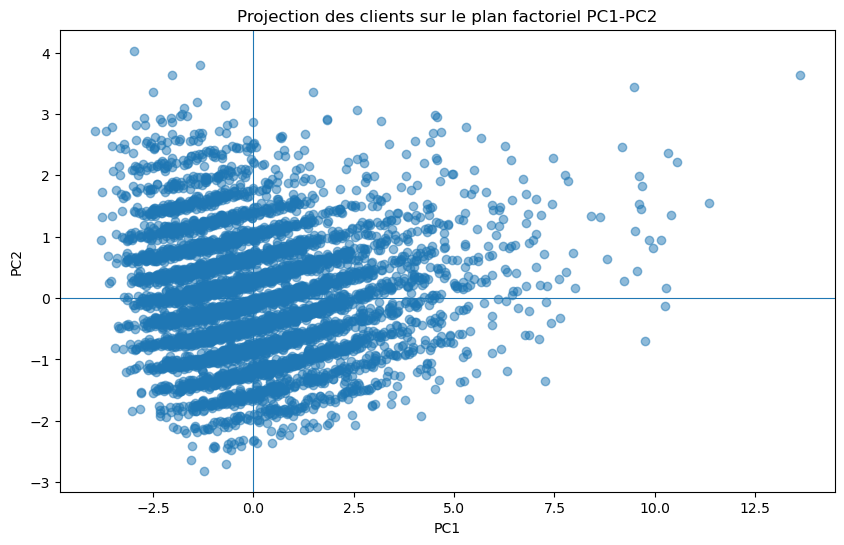

In [55]:
# Visualiser les clients sur le plan factoriel PC1-PC2

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection des clients sur le plan factoriel PC1-PC2")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()

# interpretation
L’Analyse en Composantes Principales (ACP) montre que les cinq variables financières peuvent être résumées efficacement à travers deux composantes principales. La première composante (PC1) explique 72,37 % de la variance totale et représente principalement le profil financier global des clients, en raison de sa forte association avec le revenu mensuel, le solde du compte, le montant du prêt demandé et le score de crédit. La deuxième composante (PC2) explique 18,64 % de la variance et est principalement liée aux jours de retard de paiement. Ainsi, les deux premières composantes expliquent ensemble 91,01 % de la variance totale, ce qui permet de réduire la dimension des données tout en conservant une grande partie de l’information initiale.


In [56]:
# Ajouter les coordonnées des clients sur les composantes principales

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

df[["id", "PC1", "PC2"]].head()

,id,PC1,PC2
0,1,1.785876,-0.449949
1,4,1.348008,-0.858337
2,5,2.322713,0.771771
3,6,-1.674698,-0.249072
4,7,-0.288105,1.435728


In [57]:
# Calculer la matrice de corrélation entre les variables numériques

variables_correlation = [
    "ingreso_mensual",
    "saldo_cuenta",
    "score_crediticio",
    "dias_mora_12m",
    "monto_prestamo_solicitado"
]

matrice_correlation = df[variables_correlation].corr()

matrice_correlation

,ingreso_mensual,saldo_cuenta,score_crediticio,dias_mora_12m,monto_prestamo_solicitado
ingreso_mensual,1.000000,0.939452,0.782159,-0.218150,0.947794
saldo_cuenta,0.939452,1.000000,0.735048,-0.196599,0.892612
score_crediticio,0.782159,0.735048,1.000000,-0.280483,0.769384
dias_mora_12m,-0.218150,-0.196599,-0.280483,1.000000,-0.217479
monto_prestamo_solicitado,0.947794,0.892612,0.769384,-0.217479,1.000000


# conclution
L’analyse de la matrice de corrélation met en évidence de fortes relations positives entre les principales variables financières. Le revenu mensuel présente notamment une très forte corrélation avec le montant du prêt demandé (r = 0,948) et avec le solde du compte (r = 0,939). Le solde du compte est également fortement corrélé au montant du prêt demandé (r = 0,893). Le score de crédit présente, quant à lui, des corrélations positives importantes avec le revenu, le solde et le montant du prêt. À l’inverse, les jours de retard présentent des corrélations négatives mais relativement faibles avec les variables financières. Ces résultats confirment la forte interdépendance entre les variables constituant le profil financier des clients, ce qui est cohérent avec les résultats obtenus précédemment par l’ACP. Toutefois, ces corrélations décrivent des associations statistiques et ne permettent pas d’établir des relations de causalité.


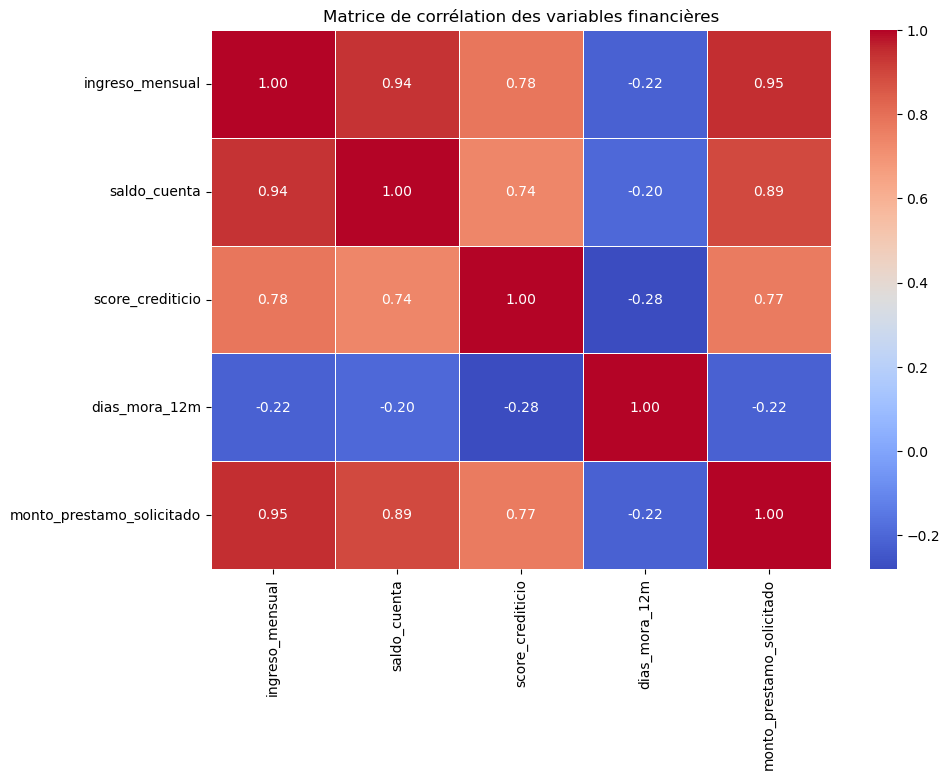

In [58]:
# Visualiser la matrice de corrélation

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    matrice_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables financières")
plt.show()

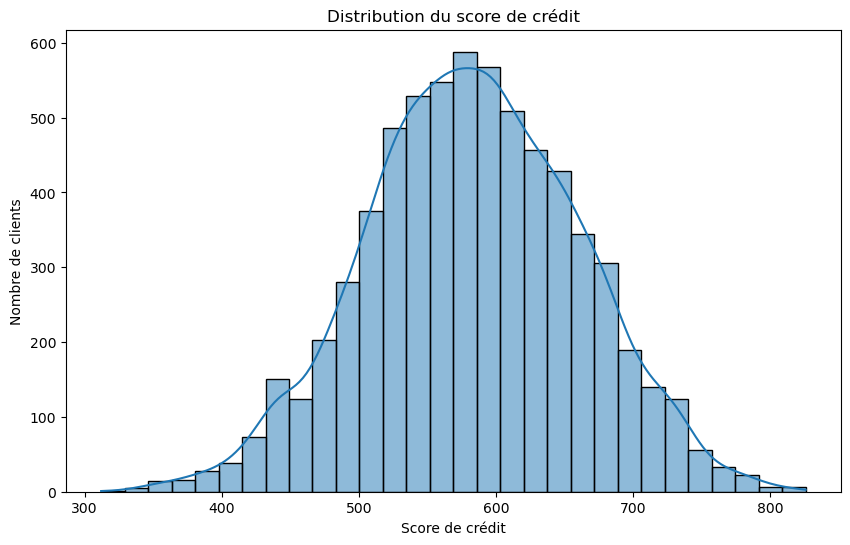

In [59]:
# Visualiser la distribution du score de crédit

plt.figure(figsize=(10, 6))

sns.histplot(
    df["score_crediticio"],
    bins=30,
    kde=True
)

plt.title("Distribution du score de crédit")
plt.xlabel("Score de crédit")
plt.ylabel("Nombre de clients")

plt.show()

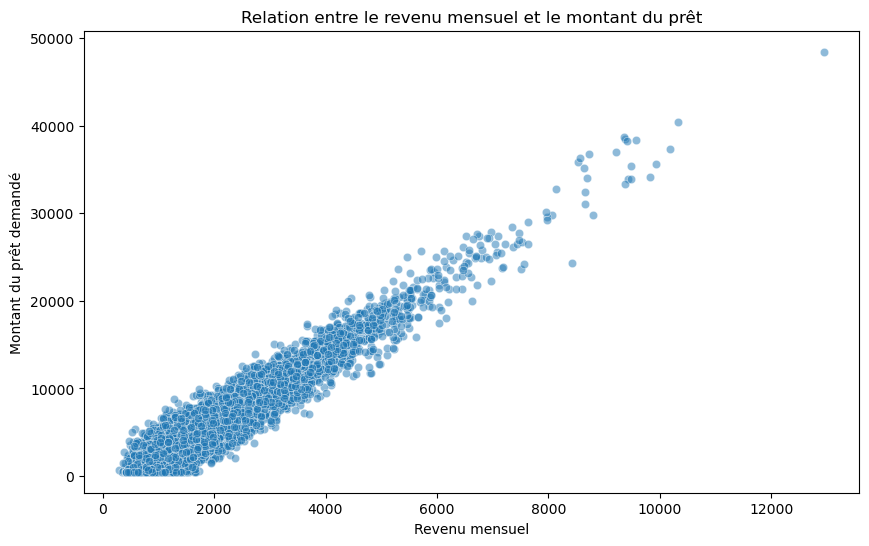

In [60]:
# Visualiser la relation entre le revenu mensuel et le montant du prêt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="ingreso_mensual",
    y="monto_prestamo_solicitado",
    alpha=0.5
)

plt.title("Relation entre le revenu mensuel et le montant du prêt")
plt.xlabel("Revenu mensuel")
plt.ylabel("Montant du prêt demandé")

plt.show()

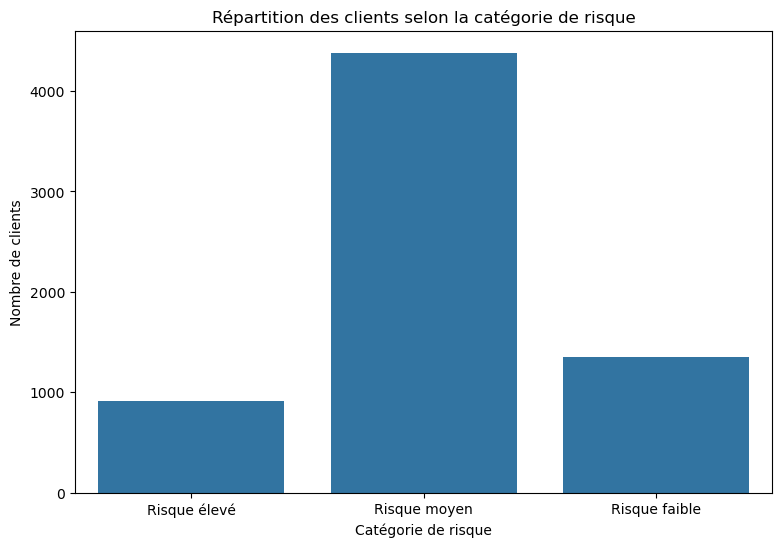

In [61]:
# Visualiser la répartition des catégories de risque

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="categorie_risque"
)

plt.title("Répartition des clients selon la catégorie de risque")
plt.xlabel("Catégorie de risque")
plt.ylabel("Nombre de clients")

plt.show()

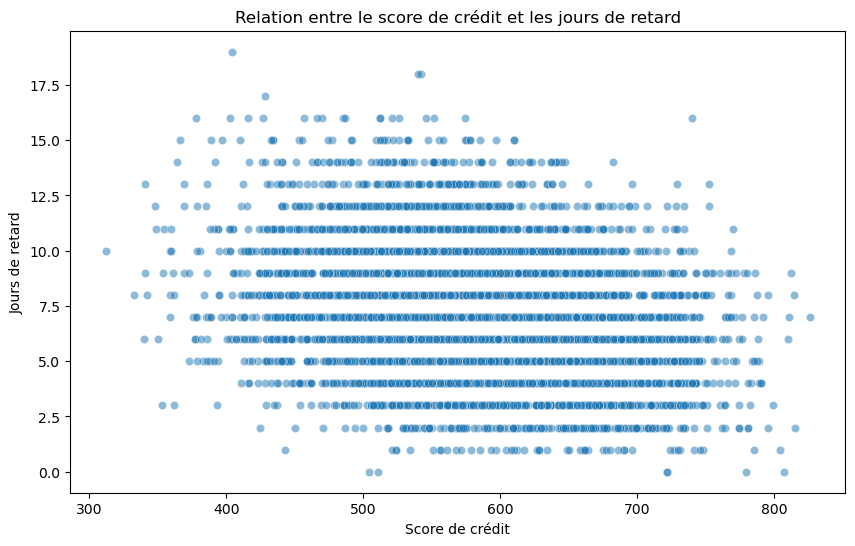

In [62]:
# Visualiser la relation entre le score de crédit et les jours de retard

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="score_crediticio",
    y="dias_mora_12m",
    alpha=0.5
)

plt.title("Relation entre le score de crédit et les jours de retard")
plt.xlabel("Score de crédit")
plt.ylabel("Jours de retard")

plt.show()

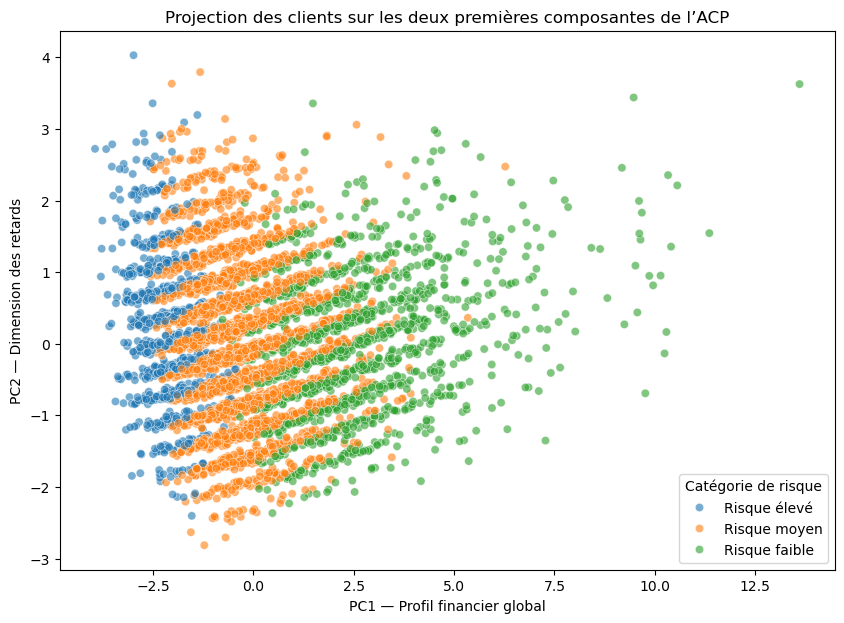

In [63]:
# Visualiser les clients selon les deux premières composantes principales

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="categorie_risque",
    alpha=0.6
)

plt.title("Projection des clients sur les deux premières composantes de l’ACP")
plt.xlabel("PC1 — Profil financier global")
plt.ylabel("PC2 — Dimension des retards")
plt.legend(title="Catégorie de risque")

plt.show()

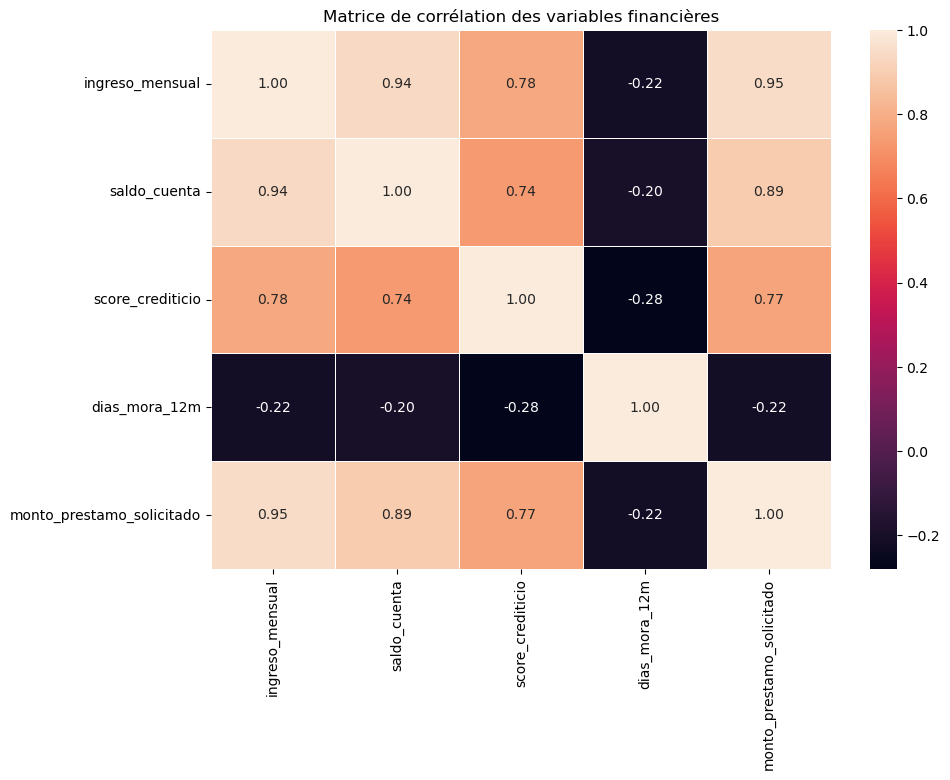

In [64]:
# Visualiser la matrice de corrélation

plt.figure(figsize=(10, 7))

sns.heatmap(
    matrice_correlation,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables financières")
plt.show()

In [65]:
# Comparer les principales variables selon la catégorie de risque

analyse_risque = df.groupby("categorie_risque")[
    [
        "ingreso_mensual",
        "saldo_cuenta",
        "score_crediticio",
        "dias_mora_12m",
        "monto_prestamo_solicitado"
    ]
].mean().round(2)

analyse_risque

C:\Users\espacegamers\AppData\Local\Temp\ipykernel_18108\2281405327.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analyse_risque = df.groupby("categorie_risque")[


,ingreso_mensual,saldo_cuenta,score_crediticio,dias_mora_12m,monto_prestamo_solicitado
categorie_risque,,,,,
Risque élevé,973.77,1763.30,457.99,8.36,2323.95
Risque moyen,1923.55,3454.40,575.61,7.25,5639.41
Risque faible,3734.25,6749.51,691.44,6.02,13088.79


In [66]:
# Créer une catégorie de revenu mensuel

df["categorie_revenu"] = pd.cut(
    df["ingreso_mensual"],
    bins=[-float("inf"), 1500, 3000, float("inf")],
    labels=["Revenu faible", "Revenu moyen", "Revenu élevé"],
    right=False
)

df["categorie_revenu"].value_counts()

categorie_revenu
Revenu moyen     3237
Revenu faible    2178
Revenu élevé     1231
Name: count, dtype: int64

In [67]:
# Croiser la catégorie de revenu et la catégorie de risque

table_revenu_risque = pd.crosstab(
    df["categorie_revenu"],
    df["categorie_risque"],
    margins=True
)

table_revenu_risque

categorie_risque,Risque élevé,Risque moyen,Risque faible,All
categorie_revenu,,,,
Revenu faible,850,1328,0,2178
Revenu moyen,65,2704,468,3237
Revenu élevé,0,349,882,1231
All,915,4381,1350,6646


In [68]:
# Vérifier les colonnes finales du DataFrame

df.columns

Index(['id', 'edad', 'genero', 'nivel_educativo', 'region', 'ingreso_mensual',
       'saldo_cuenta', 'score_crediticio', 'dias_mora_12m',
       'monto_prestamo_solicitado', 'categorie_risque', 'PC1', 'PC2',
       'categorie_revenu'],
      dtype='object')

In [69]:
# Exporter le DataFrame final vers un fichier CSV

df.to_csv(
    "banking_analysis_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Exportation terminée avec succès.")

Exportation terminée avec succès.


In [70]:
# Vérifier le fichier CSV exporté

import os

fichier = "banking_analysis_final.csv"

print("Fichier créé :", os.path.exists(fichier))
print("Taille du fichier :", round(os.path.getsize(fichier) / 1024, 2), "Ko")

Fichier créé : True
Taille du fichier : 808.81 Ko


In [71]:
# Vérification finale du nombre de lignes et de colonnes

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 6646
Nombre de colonnes : 14


In [72]:
import os

print(os.getcwd())

C:\Users\espacegamers


In [73]:
#Sélection des variables pour le Machine Learning
# Sélection des variables explicatives
X = df[
    [
        "edad",
        "genero",
        "nivel_educativo",
        "region",
        "ingreso_mensual",
        "saldo_cuenta",
        "dias_mora_12m",
        "monto_prestamo_solicitado"
    ]
]

# Variable cible
y = df["categorie_risque"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (6646, 8)
Dimensions de y : (6646,)


In [74]:
# Séparation des données en ensemble d'entraînement et ensemble de test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (5316, 8)
Dimensions de X_test  : (1330, 8)
Dimensions de y_train : (5316,)
Dimensions de y_test  : (1330,)


# Interprétation

Les données ont été divisées en deux ensembles : 80 % des observations pour l’entraînement du modèle et 20 % pour le test. L’ensemble d’entraînement contient 5 316 clients, tandis que l’ensemble de test contient 1 330 clients. La stratification permet de conserver une répartition similaire des catégories de risque dans les deux ensembles.

In [75]:
# Identification des variables numériques et catégorielles

variables_numeriques = [
    "edad",
    "ingreso_mensual",
    "saldo_cuenta",
    "dias_mora_12m",
    "monto_prestamo_solicitado"
]

variables_categorielles = [
    "genero",
    "nivel_educativo",
    "region"
]

print("Variables numériques :", variables_numeriques)
print("Variables catégorielles :", variables_categorielles)

Variables numériques : ['edad', 'ingreso_mensual', 'saldo_cuenta', 'dias_mora_12m', 'monto_prestamo_solicitado']
Variables catégorielles : ['genero', 'nivel_educativo', 'region']


In [76]:
# Encodage des variables catégorielles

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocesseur = ColumnTransformer(
    transformers=[
        (
            "categoriel",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categorielles
        )
    ],
    remainder="passthrough"
)

print("Préprocesseur créé avec succès.")

Préprocesseur créé avec succès.


# Interprétation

Les variables catégorielles ont été identifiées afin de les transformer en variables numériques à l’aide de la méthode One-Hot Encoding. Les variables numériques sont conservées sous leur forme originale. Le préprocesseur sera intégré dans une pipeline afin d’éviter toute fuite d’information entre les données d’entraînement et les données de test.

In [77]:
# Importation des outils nécessaires pour la Régression Logistique

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [78]:
# Création de la pipeline de Régression Logistique

modele_logistique = Pipeline(
    steps=[
        ("pretraitement", preprocesseur),
        ("modele", LogisticRegression(max_iter=1000))
    ]
)

print("Pipeline de Régression Logistique créée avec succès.")

Pipeline de Régression Logistique créée avec succès.


In [79]:
# Entraînement du modèle sur les données d'entraînement

modele_logistique.fit(X_train, y_train)

print("Entraînement terminé avec succès.")

Entraînement terminé avec succès.


C:\Users\espacegamers\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [80]:
# Prédiction des catégories de risque sur les données de test

y_pred = modele_logistique.predict(X_test)

print("Prédictions réalisées.")
print("Nombre de prédictions :", len(y_pred))

Prédictions réalisées.
Nombre de prédictions : 1330


# Interprétation 

Une régression logistique multiclasses a été entraînée afin de prédire la catégorie de risque des clients. Le prétraitement des variables catégorielles et l’apprentissage du modèle ont été intégrés dans une même pipeline. Les prédictions ont ensuite été réalisées sur l’ensemble de test composé de 1 330 clients.

In [81]:
# Calcul de l'Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Accuracy en pourcentage :", accuracy * 100, "%")

Accuracy : 0.7601503759398496
Accuracy en pourcentage : 76.01503759398496 %


In [82]:
# Calcul de la Precision, du Recall et du F1-score

from sklearn.metrics import classification_report

rapport = classification_report(y_test, y_pred)

print(rapport)

               precision    recall  f1-score   support

Risque faible       0.67      0.60      0.63       270
 Risque moyen       0.79      0.87      0.83       877
 Risque élevé       0.72      0.46      0.56       183

     accuracy                           0.76      1330
    macro avg       0.73      0.64      0.67      1330
 weighted avg       0.75      0.76      0.75      1330



In [83]:
# Création de la matrice de confusion

from sklearn.metrics import confusion_matrix
import pandas as pd

matrice = confusion_matrix(y_test, y_pred)

categories = modele_logistique.classes_

matrice_df = pd.DataFrame(
    matrice,
    index=categories,
    columns=categories
)

print(matrice_df)

               Risque faible  Risque moyen  Risque élevé
Risque faible            161           109             0
Risque moyen              78           766            33
Risque élevé               1            98            84


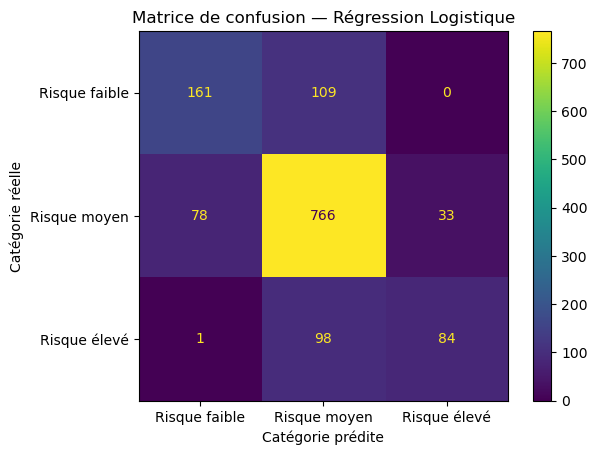

In [84]:
# Visualisation de la matrice de confusion

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=matrice,
    display_labels=categories
).plot()

plt.title("Matrice de confusion — Régression Logistique")
plt.xlabel("Catégorie prédite")
plt.ylabel("Catégorie réelle")
plt.show()

# Interprétation : 
La régression logistique permet de prédire les catégories de risque à partir des caractéristiques démographiques et financières des clients. L’évaluation repose sur l’Accuracy, la Precision, le Recall et le F1-score. La matrice de confusion permet d’identifier les catégories correctement classées ainsi que les principales erreurs de classification.

In [85]:
# Importation de l'Arbre de décision

from sklearn.tree import DecisionTreeClassifier

In [86]:
# Création de la pipeline de l'Arbre de décision

modele_arbre = Pipeline(
    steps=[
        ("pretraitement", preprocesseur),
        ("modele", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

print("Pipeline de l'Arbre de décision créée avec succès.")

Pipeline de l'Arbre de décision créée avec succès.


In [87]:
# Entraînement de l'Arbre de décision

modele_arbre.fit(X_train, y_train)

print("Entraînement de l'Arbre de décision terminé avec succès.")

Entraînement de l'Arbre de décision terminé avec succès.


In [88]:
# Prédiction sur les données de test

y_pred_arbre = modele_arbre.predict(X_test)

print("Prédictions réalisées.")
print("Nombre de prédictions :", len(y_pred_arbre))

Prédictions réalisées.
Nombre de prédictions : 1330


In [89]:
# Évaluation de l'Arbre de décision

from sklearn.metrics import accuracy_score, classification_report

accuracy_arbre = accuracy_score(y_test, y_pred_arbre)

print("Accuracy de l'Arbre de décision :", accuracy_arbre)
print("\nClassification Report :")
print(classification_report(y_test, y_pred_arbre))

Accuracy de l'Arbre de décision : 0.7954887218045112

Classification Report :
               precision    recall  f1-score   support

Risque faible       0.74      0.69      0.71       270
 Risque moyen       0.82      0.88      0.85       877
 Risque élevé       0.73      0.53      0.61       183

     accuracy                           0.80      1330
    macro avg       0.76      0.70      0.73      1330
 weighted avg       0.79      0.80      0.79      1330



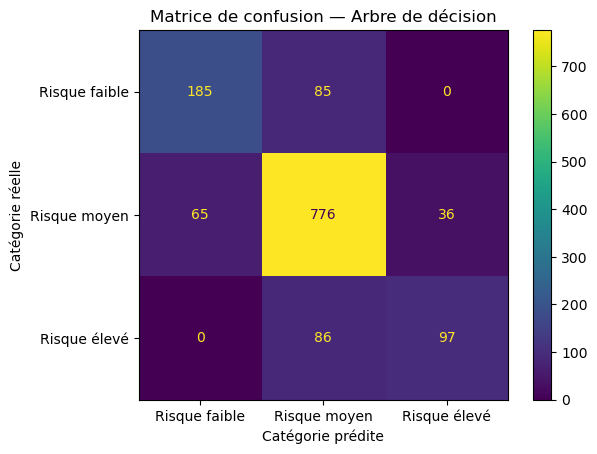

In [90]:
# Matrice de confusion de l'Arbre de décision

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrice_arbre = confusion_matrix(y_test, y_pred_arbre)

ConfusionMatrixDisplay(
    confusion_matrix=matrice_arbre,
    display_labels=modele_arbre.classes_
).plot()

plt.title("Matrice de confusion — Arbre de décision")
plt.xlabel("Catégorie prédite")
plt.ylabel("Catégorie réelle")
plt.show()

# Interprétation
Un deuxième modèle basé sur un Arbre de décision a été entraîné afin de prédire la catégorie de risque des clients. Une profondeur maximale de 5 a été utilisée afin de limiter la complexité du modèle et de réduire le risque de surapprentissage. Les performances du modèle sont ensuite évaluées à l’aide de l’Accuracy, de la Precision, du Recall, du F1-score et de la matrice de confusion.

# Comparaison des deux premiers modèles

In [91]:
# Calcul des métriques pour comparer les deux modèles

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Métriques de la Régression Logistique
accuracy_logistique = accuracy_score(y_test, y_pred)
precision_logistique = precision_score(y_test, y_pred, average="weighted")
recall_logistique = recall_score(y_test, y_pred, average="weighted")
f1_logistique = f1_score(y_test, y_pred, average="weighted")

# Métriques de l'Arbre de décision
accuracy_arbre = accuracy_score(y_test, y_pred_arbre)
precision_arbre = precision_score(y_test, y_pred_arbre, average="weighted")
recall_arbre = recall_score(y_test, y_pred_arbre, average="weighted")
f1_arbre = f1_score(y_test, y_pred_arbre, average="weighted")

In [92]:
# Tableau comparatif des performances

comparaison_modeles = pd.DataFrame({
    "Modèle": [
        "Régression Logistique",
        "Arbre de décision"
    ],
    "Accuracy": [
        accuracy_logistique,
        accuracy_arbre
    ],
    "Precision": [
        precision_logistique,
        precision_arbre
    ],
    "Recall": [
        recall_logistique,
        recall_arbre
    ],
    "F1-score": [
        f1_logistique,
        f1_arbre
    ]
})

print(comparaison_modeles)

                  Modèle  Accuracy  Precision    Recall  F1-score
0  Régression Logistique  0.760150   0.754085  0.760150  0.751279
1      Arbre de décision  0.795489   0.790907  0.795489  0.789987


In [93]:
# Affichage des métriques en pourcentage

comparaison_pourcentage = comparaison_modeles.copy()

colonnes_metriques = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

comparaison_pourcentage[colonnes_metriques] = (
    comparaison_pourcentage[colonnes_metriques] * 100
).round(2)

print(comparaison_pourcentage)

                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression Logistique     76.02      75.41   76.02     75.13
1      Arbre de décision     79.55      79.09   79.55     79.00


# Interprétation

Comparaison des modèles : Les performances de la Régression Logistique et de l’Arbre de décision sont comparées à l’aide de quatre métriques : Accuracy, Precision, Recall et F1-score. Cette comparaison permet d’évaluer la capacité des deux modèles à classer correctement les clients selon leur catégorie de risque

# Random Forest

In [94]:
# Importation du modèle Random Forest

from sklearn.ensemble import RandomForestClassifier

In [95]:
# Création de la pipeline Random Forest

modele_random_forest = Pipeline(
    steps=[
        ("pretraitement", preprocesseur),
        ("modele", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            max_depth=10
        ))
    ]
)

print("Pipeline Random Forest créée avec succès.")

Pipeline Random Forest créée avec succès.


In [96]:
# Entraînement du modèle Random Forest

modele_random_forest.fit(X_train, y_train)

print("Entraînement du Random Forest terminé avec succès.")

Entraînement du Random Forest terminé avec succès.


In [97]:
# Prédiction sur les données de test

y_pred_rf = modele_random_forest.predict(X_test)

print("Prédictions réalisées.")
print("Nombre de prédictions :", len(y_pred_rf))

Prédictions réalisées.
Nombre de prédictions : 1330


In [98]:
# Évaluation du Random Forest

from sklearn.metrics import accuracy_score, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy du Random Forest :", accuracy_rf)

print("\nClassification Report :")
print(classification_report(y_test, y_pred_rf))

Accuracy du Random Forest : 0.7984962406015037

Classification Report :
               precision    recall  f1-score   support

Risque faible       0.75      0.66      0.70       270
 Risque moyen       0.82      0.89      0.85       877
 Risque élevé       0.73      0.57      0.64       183

     accuracy                           0.80      1330
    macro avg       0.77      0.71      0.73      1330
 weighted avg       0.79      0.80      0.79      1330



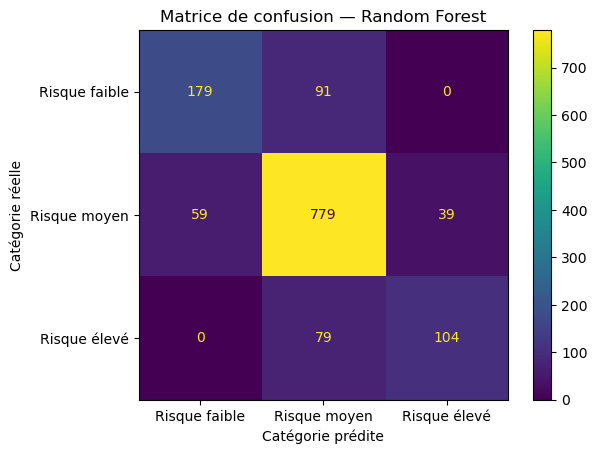

In [99]:
# Matrice de confusion du Random Forest

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrice_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=matrice_rf,
    display_labels=modele_random_forest.classes_
).plot()

plt.title("Matrice de confusion — Random Forest")
plt.xlabel("Catégorie prédite")
plt.ylabel("Catégorie réelle")
plt.show()

# Interprétation

Un modèle Random Forest a été entraîné afin de prédire la catégorie de risque des clients. Le modèle est composé de plusieurs arbres de décision, ce qui permet de prendre en compte différentes relations présentes dans les données. Ses performances sont évaluées à l’aide de l’Accuracy, de la Precision, du Recall, du F1-score et de la matrice de confusion.

In [100]:
# Calcul des métriques du Random Forest

from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Precision :", precision_rf)
print("Recall :", recall_rf)
print("F1-score :", f1_rf)

Precision : 0.794027009869194
Recall : 0.7984962406015037
F1-score : 0.7934736894155988


In [101]:
# Tableau final de comparaison des modèles

comparaison_finale = pd.DataFrame({
    "Modèle": [
        "Régression Logistique",
        "Arbre de décision",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistique,
        accuracy_arbre,
        accuracy_rf
    ],
    "Precision": [
        precision_logistique,
        precision_arbre,
        precision_rf
    ],
    "Recall": [
        recall_logistique,
        recall_arbre,
        recall_rf
    ],
    "F1-score": [
        f1_logistique,
        f1_arbre,
        f1_rf
    ]
})

print(comparaison_finale)

                  Modèle  Accuracy  Precision    Recall  F1-score
0  Régression Logistique  0.760150   0.754085  0.760150  0.751279
1      Arbre de décision  0.795489   0.790907  0.795489  0.789987
2          Random Forest  0.798496   0.794027  0.798496  0.793474


In [102]:
# Conversion des métriques en pourcentage

comparaison_finale_pct = comparaison_finale.copy()

colonnes_metriques = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

comparaison_finale_pct[colonnes_metriques] = (
    comparaison_finale_pct[colonnes_metriques] * 100
).round(2)

print(comparaison_finale_pct)

                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression Logistique     76.02      75.41   76.02     75.13
1      Arbre de décision     79.55      79.09   79.55     79.00
2          Random Forest     79.85      79.40   79.85     79.35


# Visualiser la comparaison

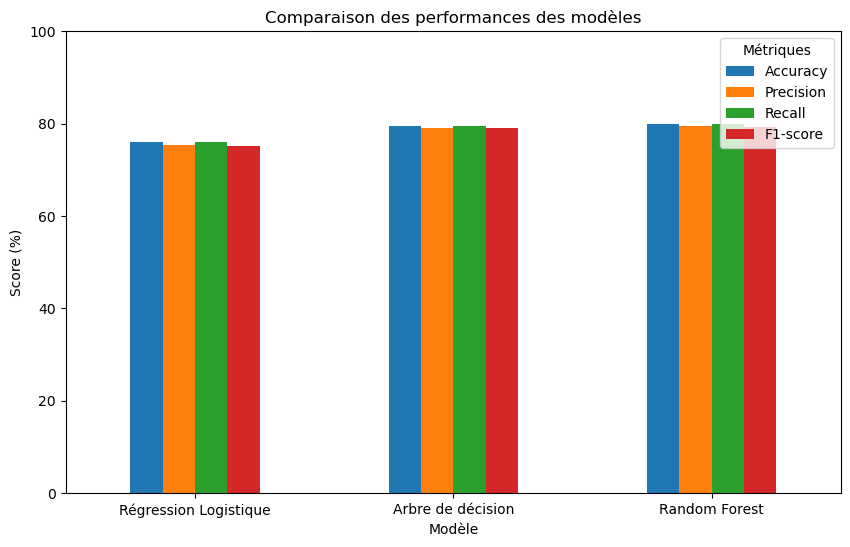

In [103]:
# Visualisation comparative des performances

comparaison_graphique = comparaison_finale_pct.set_index("Modèle")

comparaison_graphique.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparaison des performances des modèles")
plt.ylabel("Score (%)")
plt.xlabel("Modèle")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Métriques")
plt.show()

# Interprétation

Comparaison des modèles : Trois modèles de classification ont été testés pour prédire la catégorie de risque : la Régression Logistique, l’Arbre de décision et le Random Forest. Les modèles ont été évalués à partir de l’Accuracy, de la Precision, du Recall et du F1-score. Cette comparaison permet d’identifier les différences de performance entre les approches linéaires et les modèles basés sur les arbres de décision.

# KNN (K-Nearest Neighbors)

In [104]:
# Préparation du prétraitement pour le modèle KNN

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocesseur_knn = ColumnTransformer(
    transformers=[
        (
            "numerique",
            StandardScaler(),
            variables_numeriques
        ),
        (
            "categoriel",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categorielles
        )
    ]
)

print("Préprocesseur KNN créé avec succès.")

Préprocesseur KNN créé avec succès.


In [105]:
# Création de la pipeline KNN

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

modele_knn = Pipeline(
    steps=[
        ("pretraitement", preprocesseur_knn),
        ("modele", KNeighborsClassifier(n_neighbors=5))
    ]
)

print("Pipeline KNN créée avec succès.")

Pipeline KNN créée avec succès.


In [106]:
# Entraînement du modèle KNN

modele_knn.fit(X_train, y_train)

print("Entraînement du modèle KNN terminé avec succès.")

Entraînement du modèle KNN terminé avec succès.


In [107]:
# Prédiction sur les données de test

y_pred_knn = modele_knn.predict(X_test)

print("Prédictions réalisées.")
print("Nombre de prédictions :", len(y_pred_knn))

Prédictions réalisées.
Nombre de prédictions : 1330


In [108]:
# Évaluation du modèle KNN

from sklearn.metrics import accuracy_score, classification_report

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy du KNN :", accuracy_knn)

print("\nClassification Report :")
print(classification_report(y_test, y_pred_knn))

Accuracy du KNN : 0.7436090225563909

Classification Report :
               precision    recall  f1-score   support

Risque faible       0.69      0.60      0.64       270
 Risque moyen       0.78      0.86      0.82       877
 Risque élevé       0.59      0.39      0.47       183

     accuracy                           0.74      1330
    macro avg       0.69      0.62      0.64      1330
 weighted avg       0.73      0.74      0.73      1330



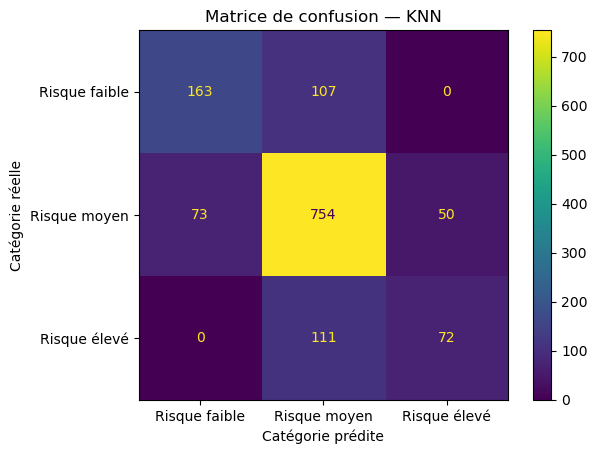

In [109]:
# Matrice de confusion du KNN

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrice_knn = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(
    confusion_matrix=matrice_knn,
    display_labels=modele_knn.classes_
).plot()

plt.title("Matrice de confusion — KNN")
plt.xlabel("Catégorie prédite")
plt.ylabel("Catégorie réelle")
plt.show()

# SVM — Support Vector Machine

In [110]:
# Création de la pipeline SVM

from sklearn.svm import SVC

modele_svm = Pipeline(
    steps=[
        ("pretraitement", preprocesseur_knn),
        ("modele", SVC(kernel="rbf"))
    ]
)

print("Pipeline SVM créée avec succès.")

Pipeline SVM créée avec succès.


In [111]:
# Entraînement du modèle SVM

modele_svm.fit(X_train, y_train)

print("Entraînement du modèle SVM terminé avec succès.")

Entraînement du modèle SVM terminé avec succès.


In [112]:
# Prédiction sur les données de test

y_pred_svm = modele_svm.predict(X_test)

print("Prédictions réalisées.")
print("Nombre de prédictions :", len(y_pred_svm))

Prédictions réalisées.
Nombre de prédictions : 1330


In [113]:
# Évaluation du modèle SVM

from sklearn.metrics import accuracy_score, classification_report

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy du SVM :", accuracy_svm)

print("\nClassification Report :")
print(classification_report(y_test, y_pred_svm))

Accuracy du SVM : 0.793233082706767

Classification Report :
               precision    recall  f1-score   support

Risque faible       0.77      0.63      0.69       270
 Risque moyen       0.81      0.90      0.85       877
 Risque élevé       0.71      0.54      0.61       183

     accuracy                           0.79      1330
    macro avg       0.76      0.69      0.72      1330
 weighted avg       0.79      0.79      0.79      1330



In [114]:
# Calcul de la matrice de confusion du SVM

from sklearn.metrics import confusion_matrix

matrice_svm = confusion_matrix(y_test, y_pred_svm)

print("Matrice de confusion du SVM :")
print(matrice_svm)

Matrice de confusion du SVM :
[[170 100   0]
 [ 50 787  40]
 [  0  85  98]]


# Interprétation

Le modèle SVM a été entraîné afin de classer les clients selon leur catégorie de risque. Les variables numériques ont été standardisées et les variables catégorielles ont été encodées avant l’apprentissage. Le modèle SVM utilise un noyau RBF afin de prendre en compte des relations potentiellement non linéaires entre les variables explicatives.

# Comparaison finale des 5 modèles

In [115]:
# Calcul des métriques du KNN

from sklearn.metrics import precision_score, recall_score, f1_score

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

print("KNN")
print("Precision :", precision_knn)
print("Recall :", recall_knn)
print("F1-score :", f1_knn)

KNN
Precision : 0.7329245377515772
Recall : 0.7436090225563909
F1-score : 0.7335433908169248


In [116]:
# Calcul des métriques du SVM

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

print("SVM")
print("Precision :", precision_svm)
print("Recall :", recall_svm)
print("F1-score :", f1_svm)

SVM
Precision : 0.7884768128538787
Recall : 0.793233082706767
F1-score : 0.7862029218511241


# Récupérer les noms des variables

In [117]:
# Récupération des noms des variables après prétraitement

noms_variables = modele_random_forest.named_steps[
    "pretraitement"
].get_feature_names_out()

print("Nombre de variables après prétraitement :", len(noms_variables))
print(noms_variables)

Nombre de variables après prétraitement : 18
['categoriel__genero_F' 'categoriel__genero_M'
 'categoriel__nivel_educativo_Postgrado'
 'categoriel__nivel_educativo_Primaria'
 'categoriel__nivel_educativo_Secundaria'
 'categoriel__nivel_educativo_Tecnico'
 'categoriel__nivel_educativo_Universitario' 'categoriel__region_Centro'
 'categoriel__region_Inconnue' 'categoriel__region_Norte'
 'categoriel__region_Occidente' 'categoriel__region_Oriente'
 'categoriel__region_Sur' 'remainder__edad' 'remainder__ingreso_mensual'
 'remainder__saldo_cuenta' 'remainder__dias_mora_12m'
 'remainder__monto_prestamo_solicitado']


In [118]:
# Extraction de l'importance des variables du Random Forest

importance_variables = modele_random_forest.named_steps[
    "modele"
].feature_importances_

print("Nombre d'importances :", len(importance_variables))

Nombre d'importances : 18


In [119]:
# Vérification des variables utilisées pour le Machine Learning

print("Colonnes de X_train :")
print(X_train.columns.tolist())

print("\nTypes des variables :")
print(X_train.dtypes)

Colonnes de X_train :
['edad', 'genero', 'nivel_educativo', 'region', 'ingreso_mensual', 'saldo_cuenta', 'dias_mora_12m', 'monto_prestamo_solicitado']

Types des variables :
edad                           int64
genero                        object
nivel_educativo               object
region                        object
ingreso_mensual              float64
saldo_cuenta                 float64
dias_mora_12m                  int64
monto_prestamo_solicitado    float64
dtype: object


In [120]:
# Prétraitement des variables numériques et catégorielles

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Variables numériques
variables_numeriques = [
    "edad",
    "ingreso_mensual",
    "saldo_cuenta",
    "dias_mora_12m",
    "monto_prestamo_solicitado"
]

# Variables catégorielles
variables_categorielles = [
    "genero",
    "nivel_educativo",
    "region"
]

# Préprocesseur
preprocesseur = ColumnTransformer(
    transformers=[
        ("numerique", "passthrough", variables_numeriques),
        ("categoriel", OneHotEncoder(handle_unknown="ignore"), variables_categorielles)
    ]
)

# Transformation des données
X_train_prepare = preprocesseur.fit_transform(X_train)
X_test_prepare = preprocesseur.transform(X_test)

print("Prétraitement terminé.")
print("X_train_prepare :", X_train_prepare.shape)
print("X_test_prepare :", X_test_prepare.shape)

Prétraitement terminé.
X_train_prepare : (5316, 18)
X_test_prepare : (1330, 18)


In [121]:
# Entraînement des 5 modèles de classification

# 1. Régression logistique
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_prepare, y_train)

# 2. Arbre de décision
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_prepare, y_train)

# 3. Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest_model.fit(X_train_prepare, y_train)

# 4. KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_prepare, y_train)

# 5. SVM
svm_model = SVC()
svm_model.fit(X_train_prepare, y_train)

print("Les 5 modèles ont été entraînés avec succès.")

C:\Users\espacegamers\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Les 5 modèles ont été entraînés avec succès.


In [122]:
# Prédictions des 5 modèles

y_pred_logistic = logistic_model.predict(X_test_prepare)
y_pred_tree = decision_tree_model.predict(X_test_prepare)
y_pred_forest = random_forest_model.predict(X_test_prepare)
y_pred_knn = knn_model.predict(X_test_prepare)
y_pred_svm = svm_model.predict(X_test_prepare)

print("Les prédictions des 5 modèles ont été réalisées avec succès.")

Les prédictions des 5 modèles ont été réalisées avec succès.


In [123]:
# Calcul des métriques de performance

resultats_5_modeles = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_logistic, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_tree, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_forest, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_logistic, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_tree, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_forest, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)
    ],
    
    "F1-score": [
        f1_score(y_test, y_pred_logistic, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_tree, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_forest, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)
    ]
})

print(resultats_5_modeles.round(4))

                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression logistique    0.7850     0.7792  0.7850    0.7773
1      Arbre de décision    0.7158     0.7235  0.7158    0.7188
2          Random Forest    0.7887     0.7841  0.7887    0.7843
3                    KNN    0.7774     0.7744  0.7774    0.7749
4                    SVM    0.7842     0.7787  0.7842    0.7741


In [124]:
# Conversion des métriques en pourcentage

comparaison_5_modeles_pct = resultats_5_modeles.copy()

colonnes_metriques = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

comparaison_5_modeles_pct[colonnes_metriques] = (
    comparaison_5_modeles_pct[colonnes_metriques] * 100
).round(2)

print(comparaison_5_modeles_pct)

                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression logistique     78.50      77.92   78.50     77.73
1      Arbre de décision     71.58      72.35   71.58     71.88
2          Random Forest     78.87      78.41   78.87     78.43
3                    KNN     77.74      77.44   77.74     77.49
4                    SVM     78.42      77.87   78.42     77.41


In [125]:
# ============================================================
# COMPARAISON DES PERFORMANCES DES 5 MODÈLES
# ============================================================

# 1. Création du tableau des résultats
resultats_5_modeles = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest",
        "KNN",
        "SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_logistic, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_tree, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_forest, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_pred_logistic, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_tree, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_forest, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)
    ],

    "F1-score": [
        f1_score(y_test, y_pred_logistic, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_tree, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_forest, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)
    ]
})


# 2. Affichage des résultats bruts
print("=== Résultats des 5 modèles ===")
print(resultats_5_modeles.round(4))


# 3. Conversion en pourcentage
comparaison_5_modeles_pct = resultats_5_modeles.copy()

colonnes_metriques = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

comparaison_5_modeles_pct[colonnes_metriques] = (
    comparaison_5_modeles_pct[colonnes_metriques] * 100
).round(2)


# 4. Affichage du tableau en pourcentage
print("\n=== Performances des 5 modèles en pourcentage ===")
print(comparaison_5_modeles_pct)


# 5. Préparation du graphique
comparaison_graphique_5 = comparaison_5_modeles_pct.set_index("Modèle")


=== Résultats des 5 modèles ===
                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression logistique    0.7850     0.7792  0.7850    0.7773
1      Arbre de décision    0.7158     0.7235  0.7158    0.7188
2          Random Forest    0.7887     0.7841  0.7887    0.7843
3                    KNN    0.7774     0.7744  0.7774    0.7749
4                    SVM    0.7842     0.7787  0.7842    0.7741

=== Performances des 5 modèles en pourcentage ===
                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression logistique     78.50      77.92   78.50     77.73
1      Arbre de décision     71.58      72.35   71.58     71.88
2          Random Forest     78.87      78.41   78.87     78.43
3                    KNN     77.74      77.44   77.74     77.49
4                    SVM     78.42      77.87   78.42     77.41


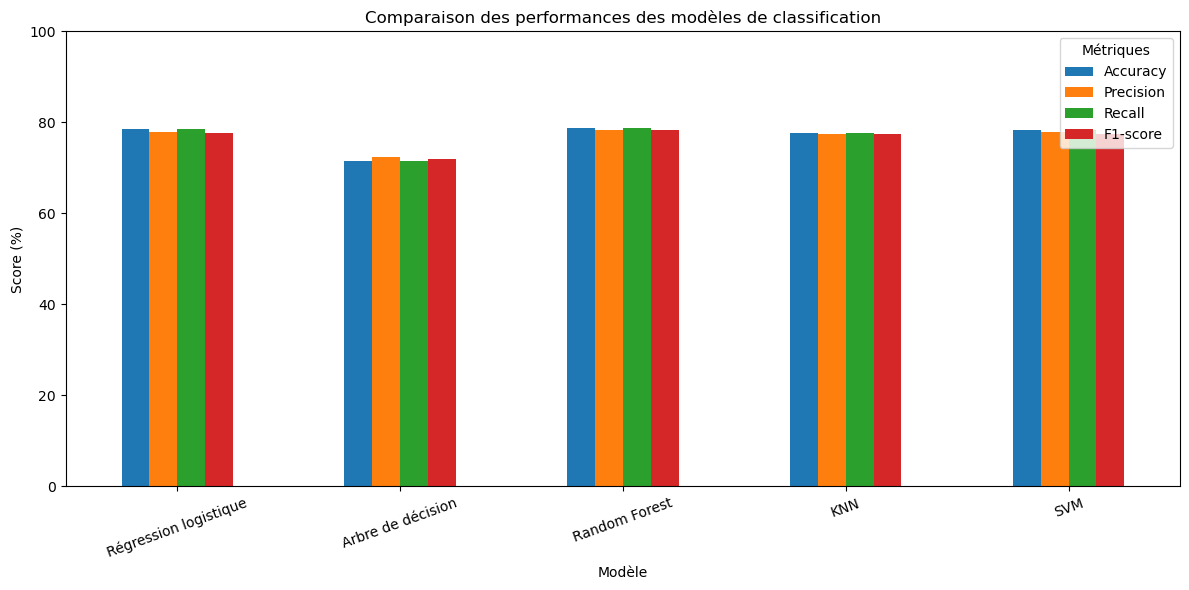

In [126]:
# 6. Création du graphique
import matplotlib.pyplot as plt

comparaison_graphique_5.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparaison des performances des modèles de classification")
plt.ylabel("Score (%)")
plt.xlabel("Modèle")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.legend(title="Métriques")
plt.tight_layout()
plt.show()

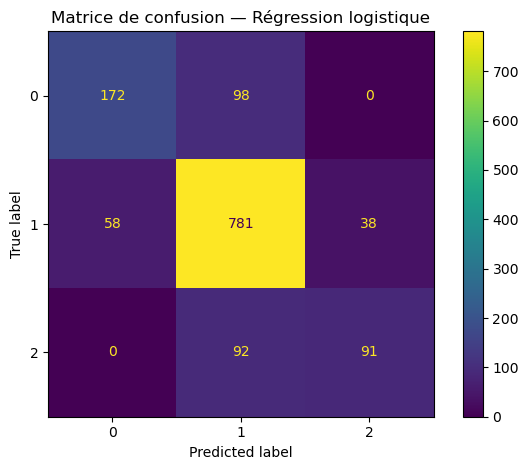

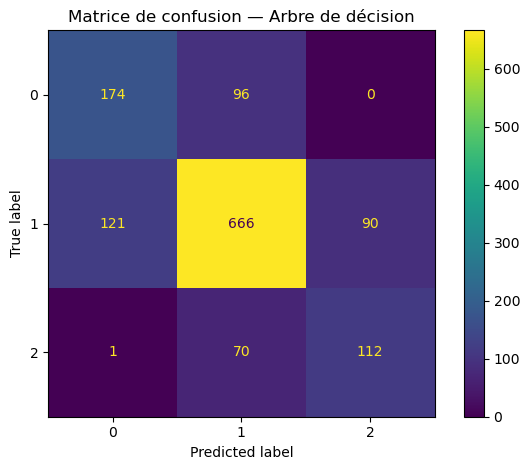

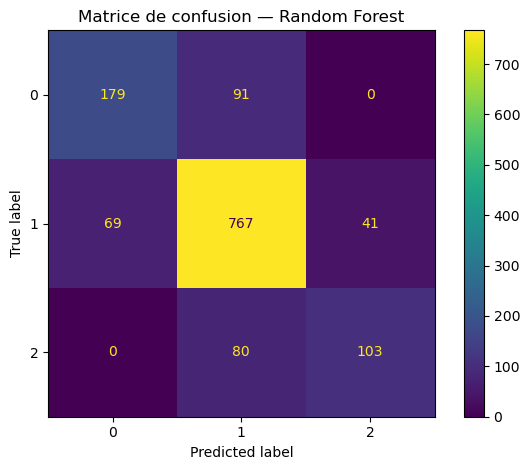

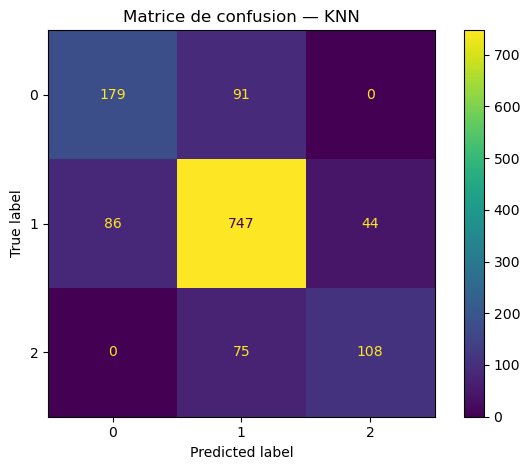

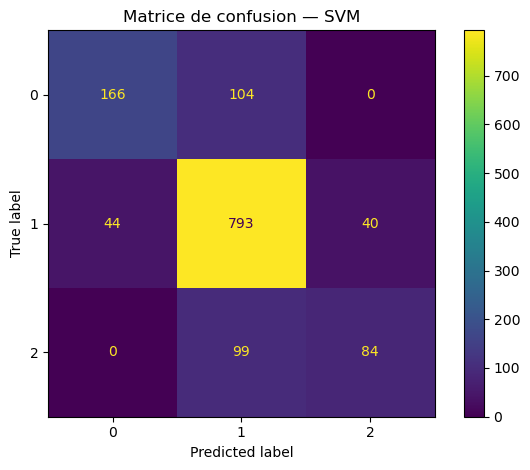

In [127]:
# ============================================================
# MATRICES DE CONFUSION DES 5 MODÈLES
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# 1. Matrice de confusion — Régression logistique

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic)
disp.plot()

plt.title("Matrice de confusion — Régression logistique")
plt.tight_layout()
plt.show()


# 2. Matrice de confusion — Arbre de décision

cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()

plt.title("Matrice de confusion — Arbre de décision")
plt.tight_layout()
plt.show()


# 3. Matrice de confusion — Random Forest

cm_forest = confusion_matrix(y_test, y_pred_forest)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest)
disp.plot()

plt.title("Matrice de confusion — Random Forest")
plt.tight_layout()
plt.show()


# 4. Matrice de confusion — KNN

cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()

plt.title("Matrice de confusion — KNN")
plt.tight_layout()
plt.show()


# 5. Matrice de confusion — SVM

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()

plt.title("Matrice de confusion — SVM")
plt.tight_layout()
plt.show()


In [128]:
# ============================================================
# CLASSIFICATION REPORT DES 5 MODÈLES
# ============================================================

from sklearn.metrics import classification_report


print("=" * 60)
print("RÉGRESSION LOGISTIQUE")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred_logistic,
    zero_division=0
))


print("=" * 60)
print("ARBRE DE DÉCISION")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred_tree,
    zero_division=0
))


print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred_forest,
    zero_division=0
))


print("=" * 60)
print("KNN")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred_knn,
    zero_division=0
))


print("=" * 60)
print("SVM")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

RÉGRESSION LOGISTIQUE
               precision    recall  f1-score   support

Risque faible       0.75      0.64      0.69       270
 Risque moyen       0.80      0.89      0.85       877
 Risque élevé       0.71      0.50      0.58       183

     accuracy                           0.78      1330
    macro avg       0.75      0.67      0.71      1330
 weighted avg       0.78      0.78      0.78      1330

ARBRE DE DÉCISION
               precision    recall  f1-score   support

Risque faible       0.59      0.64      0.61       270
 Risque moyen       0.80      0.76      0.78       877
 Risque élevé       0.55      0.61      0.58       183

     accuracy                           0.72      1330
    macro avg       0.65      0.67      0.66      1330
 weighted avg       0.72      0.72      0.72      1330

RANDOM FOREST
               precision    recall  f1-score   support

Risque faible       0.72      0.66      0.69       270
 Risque moyen       0.82      0.87      0.85       877
 Ris

In [129]:
# ============================================================
# IMPORTANCE DES VARIABLES — RANDOM FOREST
# ============================================================

# Récupérer les variables après le One-Hot Encoding
noms_variables = preprocesseur.get_feature_names_out()

# Récupérer l'importance des variables
importances = random_forest_model.feature_importances_

# Créer un DataFrame
importance_df = pd.DataFrame({
    "Variable": noms_variables,
    "Importance": importances
})

# Trier les variables par importance décroissante
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Afficher les résultats
print("=== Importance des variables ===")
print(importance_df.round(4))

=== Importance des variables ===
                                     Variable  Importance
0                  numerique__ingreso_mensual      0.2918
1        numerique__monto_prestamo_solicitado      0.2461
2                     numerique__saldo_cuenta      0.1874
3                             numerique__edad      0.0902
4                    numerique__dias_mora_12m      0.0646
5                   categoriel__region_Centro      0.0117
6                    categoriel__region_Norte      0.0103
7                        categoriel__genero_F      0.0103
8                categoriel__region_Occidente      0.0102
9                        categoriel__genero_M      0.0101
10                     categoriel__region_Sur      0.0101
11  categoriel__nivel_educativo_Universitario      0.0100
12     categoriel__nivel_educativo_Secundaria      0.0095
13        categoriel__nivel_educativo_Tecnico      0.0090
14       categoriel__nivel_educativo_Primaria      0.0090
15                 categoriel__region_O

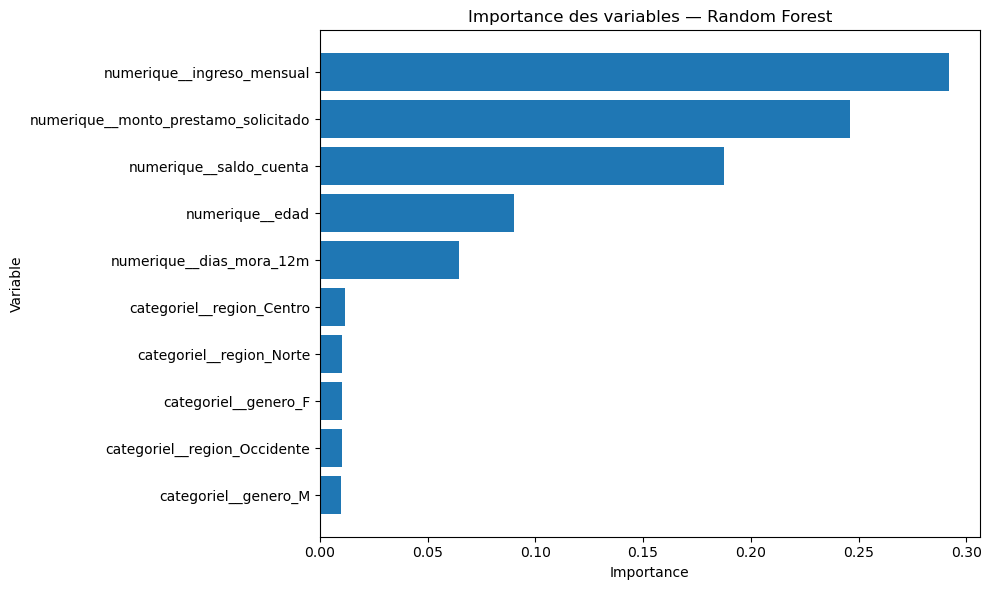

In [130]:
# ============================================================
# TOP 10 DES VARIABLES LES PLUS IMPORTANTES
# ============================================================

importance_graphique = importance_df.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_graphique["Variable"],
    importance_graphique["Importance"]
)

plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

In [131]:
# ============================================================
# TRADUCTION DES NOMS DES VARIABLES EN FRANÇAIS
# ============================================================

importance_df_final = importance_df.copy()

dictionnaire_noms = {
    "remainder__edad": "Âge",
    "remainder__ingreso_mensual": "Revenu mensuel",
    "remainder__saldo_cuenta": "Solde du compte",
    "remainder__score_crediticio": "Score de crédit",
    "remainder__dias_mora_12m": "Jours de retard",
    "remainder__monto_prestamo_solicitado": "Montant du prêt demandé",

    "categoriel__genero_F": "Genre – Femme",
    "categoriel__genero_M": "Genre – Homme",

    "categoriel__nivel_educativo_Primaria": "Niveau d’éducation – Primaire",
    "categoriel__nivel_educativo_Secundaria": "Niveau d’éducation – Secondaire",
    "categoriel__nivel_educativo_Tecnico": "Niveau d’éducation – Technique",
    "categoriel__nivel_educativo_Universitario": "Niveau d’éducation – Universitaire",
    "categoriel__nivel_educativo_Postgrado": "Niveau d’éducation – Postgraduate",

    "categoriel__region_Centro": "Région – Centre",
    "categoriel__region_Norte": "Région – Nord",
    "categoriel__region_Sur": "Région – Sud",
    "categoriel__region_Oriente": "Région – Est",
    "categoriel__region_Occidente": "Région – Ouest",
    "categoriel__region_Inconnu": "Région – Inconnue"
}

importance_df_final["Variable"] = (
    importance_df_final["Variable"].replace(dictionnaire_noms)
)

print("=== Importance des variables avec noms français ===")
print(importance_df_final.round(4))

=== Importance des variables avec noms français ===
                                Variable  Importance
0             numerique__ingreso_mensual      0.2918
1   numerique__monto_prestamo_solicitado      0.2461
2                numerique__saldo_cuenta      0.1874
3                        numerique__edad      0.0902
4               numerique__dias_mora_12m      0.0646
5                        Région – Centre      0.0117
6                          Région – Nord      0.0103
7                          Genre – Femme      0.0103
8                         Région – Ouest      0.0102
9                          Genre – Homme      0.0101
10                          Région – Sud      0.0101
11    Niveau d’éducation – Universitaire      0.0100
12       Niveau d’éducation – Secondaire      0.0095
13        Niveau d’éducation – Technique      0.0090
14         Niveau d’éducation – Primaire      0.0090
15                          Région – Est      0.0088
16     Niveau d’éducation – Postgraduate      0

In [132]:
# ============================================================
# TOP 10 FINAL POUR LE GRAPHIQUE
# ============================================================

importance_graphique_final = (
    importance_df_final
    .head(10)
    .sort_values(by="Importance", ascending=True)
    .copy()
)

print("=== Top 10 des variables les plus importantes ===")
print(importance_graphique_final.round(4))

=== Top 10 des variables les plus importantes ===
                               Variable  Importance
9                         Genre – Homme      0.0101
8                        Région – Ouest      0.0102
7                         Genre – Femme      0.0103
6                         Région – Nord      0.0103
5                       Région – Centre      0.0117
4              numerique__dias_mora_12m      0.0646
3                       numerique__edad      0.0902
2               numerique__saldo_cuenta      0.1874
1  numerique__monto_prestamo_solicitado      0.2461
0            numerique__ingreso_mensual      0.2918


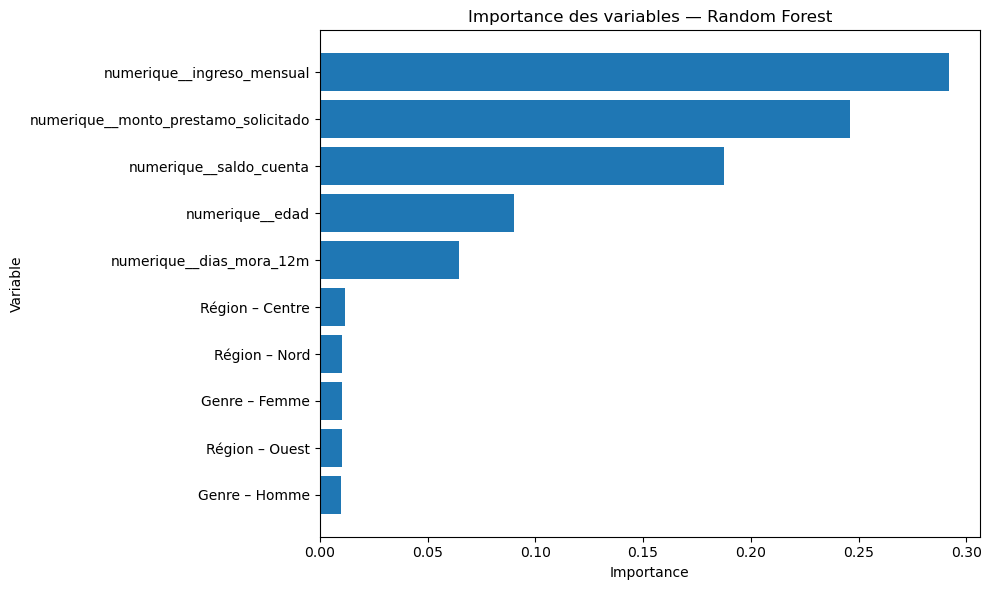

In [133]:
# ============================================================
# GRAPHIQUE FINAL — TOP 10 DES VARIABLES
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    importance_graphique_final["Variable"],
    importance_graphique_final["Importance"]
)

plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

In [134]:
# ============================================================
# TABLES FINALES POUR POWER BI
# ============================================================

# Tableau des performances des 5 modèles
comparaison_finale_5_modeles = comparaison_5_modeles_pct.copy()

# Tableau de l'importance des variables
importance_finale_powerbi = importance_df_final.copy()

print("=== Table performances ===")
print(comparaison_finale_5_modeles)

print("\n=== Table importance ===")
print(importance_finale_powerbi.round(4))

=== Table performances ===
                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression logistique     78.50      77.92   78.50     77.73
1      Arbre de décision     71.58      72.35   71.58     71.88
2          Random Forest     78.87      78.41   78.87     78.43
3                    KNN     77.74      77.44   77.74     77.49
4                    SVM     78.42      77.87   78.42     77.41

=== Table importance ===
                                Variable  Importance
0             numerique__ingreso_mensual      0.2918
1   numerique__monto_prestamo_solicitado      0.2461
2                numerique__saldo_cuenta      0.1874
3                        numerique__edad      0.0902
4               numerique__dias_mora_12m      0.0646
5                        Région – Centre      0.0117
6                          Région – Nord      0.0103
7                          Genre – Femme      0.0103
8                         Région – Ouest      0.0102
9                          Genre 

In [135]:
# ============================================================
# EXPORT DES RÉSULTATS POUR POWER BI
# ============================================================

# 1. Export des performances des 5 modèles
comparaison_finale_5_modeles.to_csv(
    "comparaison_5_modeles.csv",
    index=False,
    encoding="utf-8-sig"
)

# 2. Export de l'importance des variables
importance_finale_powerbi.to_csv(
    "importance_variables.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Les deux fichiers CSV ont été créés avec succès.")
print("1. comparaison_5_modeles.csv")
print("2. importance_variables.csv")

Les deux fichiers CSV ont été créés avec succès.
1. comparaison_5_modeles.csv
2. importance_variables.csv


In [136]:
# Vérification des fichiers exportés

import os

print("comparaison_5_modeles.csv :", os.path.exists("comparaison_5_modeles.csv"))
print("importance_variables.csv :", os.path.exists("importance_variables.csv"))

comparaison_5_modeles.csv : True
importance_variables.csv : True


In [137]:
# ============================================================
# RÉENTRAÎNEMENT DES 5 MODÈLES POUR ROC / AUC
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 1. Régression logistique
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_prepare, y_train)

# 2. Arbre de décision
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_prepare, y_train)

# 3. Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest_model.fit(X_train_prepare, y_train)

# 4. KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_prepare, y_train)

# 5. SVM avec probabilités
svm_model_roc = SVC(
    probability=True,
    random_state=42
)
svm_model_roc.fit(X_train_prepare, y_train)

print("Les 5 modèles ont été réentraînés avec succès.")

C:\Users\espacegamers\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Les 5 modèles ont été réentraînés avec succès.


In [138]:
# ============================================================
# ROC / AUC MULTICLASS — PRÉPARATION
# ============================================================

from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import numpy as np
import matplotlib.pyplot as plt

# Réentraîner le SVM avec les probabilités activées
svm_model_roc = SVC(
    probability=True,
    random_state=42
)

svm_model_roc.fit(X_train_prepare, y_train)

# Probabilités prédites par les 5 modèles
y_score_logistic = logistic_model.predict_proba(X_test_prepare)
y_score_tree = decision_tree_model.predict_proba(X_test_prepare)
y_score_forest = random_forest_model.predict_proba(X_test_prepare)
y_score_knn = knn_model.predict_proba(X_test_prepare)
y_score_svm = svm_model_roc.predict_proba(X_test_prepare)

print("Probabilités des 5 modèles calculées avec succès.")

Probabilités des 5 modèles calculées avec succès.


In [139]:
# ============================================================
# ROC / AUC MULTICLASS POUR LES 5 MODÈLES
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Récupérer les classes dans le bon ordre
classes = logistic_model.classes_

# Transformer y_test en format binaire
y_test_bin = label_binarize(y_test, classes=classes)

print("Classes :", classes)
print("Nombre de classes :", len(classes))


# ------------------------------------------------------------
# Fonction pour calculer l'AUC multiclass
# ------------------------------------------------------------

def calcul_auc_multiclass(y_test_bin, y_score):
    
    auc_classes = []
    
    for i in range(y_test_bin.shape[1]):
        
        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )
        
        auc_classe = auc(fpr, tpr)
        auc_classes.append(auc_classe)
    
    return np.mean(auc_classes)


# ------------------------------------------------------------
# Calcul AUC pour chaque modèle
# ------------------------------------------------------------

auc_logistic = calcul_auc_multiclass(
    y_test_bin,
    y_score_logistic
)

auc_tree = calcul_auc_multiclass(
    y_test_bin,
    y_score_tree
)

auc_forest = calcul_auc_multiclass(
    y_test_bin,
    y_score_forest
)

auc_knn = calcul_auc_multiclass(
    y_test_bin,
    y_score_knn
)

auc_svm = calcul_auc_multiclass(
    y_test_bin,
    y_score_svm
)


# ------------------------------------------------------------
# Affichage
# ------------------------------------------------------------

print("\n=== AUC multiclass ===")

print("Régression logistique :", round(auc_logistic, 4))
print("Arbre de décision     :", round(auc_tree, 4))
print("Random Forest         :", round(auc_forest, 4))
print("KNN                   :", round(auc_knn, 4))
print("SVM                   :", round(auc_svm, 4))

Classes : ['Risque faible' 'Risque moyen' 'Risque élevé']
Nombre de classes : 3

=== AUC multiclass ===
Régression logistique : 0.883
Arbre de décision     : 0.7426
Random Forest         : 0.8942
KNN                   : 0.8634
SVM                   : 0.8898


In [140]:
# ============================================================
# TABLEAU COMPARATIF DES AUC
# ============================================================

auc_comparaison = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    
    "AUC": [
        auc_logistic,
        auc_tree,
        auc_forest,
        auc_knn,
        auc_svm
    ]
})

auc_comparaison["AUC (%)"] = (
    auc_comparaison["AUC"] * 100
).round(2)

auc_comparaison["AUC"] = auc_comparaison["AUC"].round(4)

print(auc_comparaison)

                  Modèle     AUC  AUC (%)
0  Régression logistique  0.8830    88.30
1      Arbre de décision  0.7426    74.26
2          Random Forest  0.8942    89.42
3                    KNN  0.8634    86.34
4                    SVM  0.8898    88.98


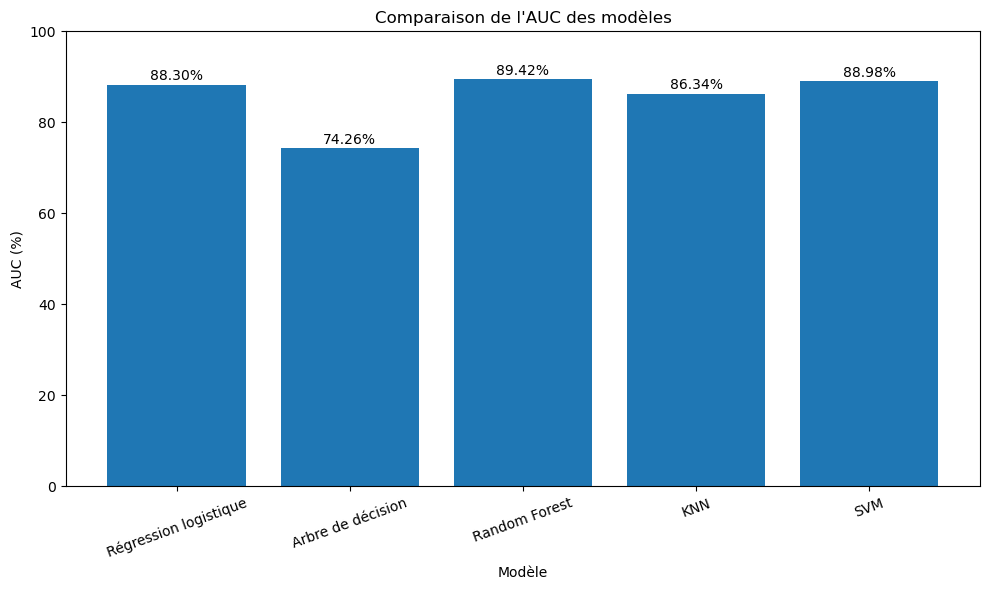

In [141]:
# ============================================================
# GRAPHIQUE COMPARATIF DES AUC
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    auc_comparaison["Modèle"],
    auc_comparaison["AUC (%)"]
)

plt.title("Comparaison de l'AUC des modèles")
plt.xlabel("Modèle")
plt.ylabel("AUC (%)")

plt.ylim(0, 100)
plt.xticks(rotation=20)

# Afficher les valeurs sur les barres
for i, valeur in enumerate(auc_comparaison["AUC (%)"]):
    plt.text(
        i,
        valeur + 1,
        f"{valeur:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

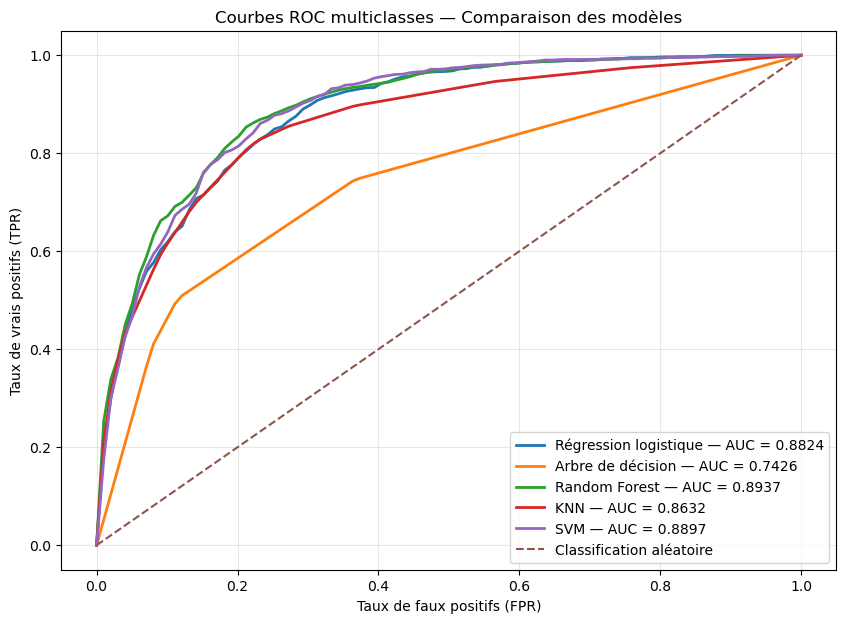

In [142]:
# ============================================================
# COURBES ROC MULTICLASSES POUR LES 5 MODÈLES
# ============================================================

from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Dictionnaire contenant les scores de probabilité
modeles_scores = {
    "Régression logistique": y_score_logistic,
    "Arbre de décision": y_score_tree,
    "Random Forest": y_score_forest,
    "KNN": y_score_knn,
    "SVM": y_score_svm
}

# Axe FPR commun pour construire les courbes macro-moyennes
fpr_commun = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 7))

resultats_roc = []

for nom_modele, y_score in modeles_scores.items():

    tpr_classes = []

    # Calcul de la ROC pour chaque classe
    for i in range(y_test_bin.shape[1]):

        fpr, tpr, seuils = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        # Interpolation sur un axe FPR commun
        tpr_interpole = np.interp(
            fpr_commun,
            fpr,
            tpr
        )

        tpr_classes.append(tpr_interpole)

    # Moyenne des TPR des 3 classes
    tpr_macro = np.mean(
        tpr_classes,
        axis=0
    )

    # Points de départ et d'arrivée
    tpr_macro[0] = 0
    tpr_macro[-1] = 1

    # AUC de la courbe ROC macro
    auc_macro = auc(
        fpr_commun,
        tpr_macro
    )

    # Ajouter le résultat au tableau
    resultats_roc.append({
        "Modèle": nom_modele,
        "AUC ROC": auc_macro
    })

    # Tracer la courbe
    plt.plot(
        fpr_commun,
        tpr_macro,
        linewidth=2,
        label=f"{nom_modele} — AUC = {auc_macro:.4f}"
    )

# Ligne de référence d'un classifieur aléatoire
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Classification aléatoire"
)

# Mise en forme
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC multiclasses — Comparaison des modèles")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [143]:
# Création du tableau des résultats ROC
roc_comparaison = pd.DataFrame(resultats_roc)

# Arrondir l'AUC
roc_comparaison["AUC ROC"] = roc_comparaison["AUC ROC"].round(4)

# Ajouter le pourcentage
roc_comparaison["AUC ROC (%)"] = (
    roc_comparaison["AUC ROC"] * 100
).round(2)

roc_comparaison

,Modèle,AUC ROC,AUC ROC (%)
0,Régression logistique,0.8824,88.24
1,Arbre de décision,0.7426,74.26
2,Random Forest,0.8937,89.37
3,KNN,0.8632,86.32
4,SVM,0.8897,88.97


In [145]:
# ============================================================
# VALIDATION CROISÉE — CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

In [146]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [147]:
from sklearn.pipeline import Pipeline

pipeline_logistic = Pipeline([
    ("preprocessing", preprocesseur),
    ("model", LogisticRegression(max_iter=1000))
])

scores_logistic_cv = cross_val_score(
    pipeline_logistic,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Scores des 5 folds :", scores_logistic_cv)
print("Accuracy moyenne :", scores_logistic_cv.mean())
print("Écart-type :", scores_logistic_cv.std())

C:\Users\espacegamers\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\espacegamers\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.h

Scores des 5 folds : [0.76390977 0.77878104 0.77426637 0.79006772 0.76072235]
Accuracy moyenne : 0.7735494492438773
Écart-type : 0.010565932348788477


C:\Users\espacegamers\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [148]:
pipeline_tree = Pipeline([
    ("preprocessing", preprocesseur),
    ("model", DecisionTreeClassifier(random_state=42))
])

scores_tree_cv = cross_val_score(
    pipeline_tree,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Scores des 5 folds :", scores_tree_cv)
print("Accuracy moyenne :", scores_tree_cv.mean())
print("Écart-type :", scores_tree_cv.std())

Scores des 5 folds : [0.70451128 0.72310008 0.69676448 0.72911964 0.68698269]
Accuracy moyenne : 0.7080956341191579
Écart-type : 0.015837555591832597


In [149]:
pipeline_forest = Pipeline([
    ("preprocessing", preprocesseur),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

scores_forest_cv = cross_val_score(
    pipeline_forest,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Scores des 5 folds :", scores_forest_cv)
print("Accuracy moyenne :", scores_forest_cv.mean())
print("Écart-type :", scores_forest_cv.std())

Scores des 5 folds : [0.77368421 0.79458239 0.79382995 0.81339353 0.78179082]
Accuracy moyenne : 0.7914561799532691
Écart-type : 0.013460440833441653


In [150]:
pipeline_knn = Pipeline([
    ("preprocessing", preprocesseur),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

scores_knn_cv = cross_val_score(
    pipeline_knn,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Scores des 5 folds :", scores_knn_cv)
print("Accuracy moyenne :", scores_knn_cv.mean())
print("Écart-type :", scores_knn_cv.std())

Scores des 5 folds : [0.76015038 0.77276147 0.77878104 0.77802859 0.76523702]
Accuracy moyenne : 0.770991700470137
Écart-type : 0.007266008572010241


In [151]:
pipeline_svm = Pipeline([
    ("preprocessing", preprocesseur),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

scores_svm_cv = cross_val_score(
    pipeline_svm,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Scores des 5 folds :", scores_svm_cv)
print("Accuracy moyenne :", scores_svm_cv.mean())
print("Écart-type :", scores_svm_cv.std())

Scores des 5 folds : [0.77443609 0.79157261 0.80285929 0.80361174 0.77577126]
Accuracy moyenne : 0.7896501977290857
Écart-type : 0.01262691211698584


In [152]:
resultats_cross_validation = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    
    "Accuracy moyenne": [
        scores_logistic_cv.mean(),
        scores_tree_cv.mean(),
        scores_forest_cv.mean(),
        scores_knn_cv.mean(),
        scores_svm_cv.mean()
    ],
    
    "Écart-type": [
        scores_logistic_cv.std(),
        scores_tree_cv.std(),
        scores_forest_cv.std(),
        scores_knn_cv.std(),
        scores_svm_cv.std()
    ]
})

resultats_cross_validation

,Modèle,Accuracy moyenne,Écart-type
0,Régression logistique,0.773549,0.010566
1,Arbre de décision,0.708096,0.015838
2,Random Forest,0.791456,0.013460
3,KNN,0.770992,0.007266
4,SVM,0.789650,0.012627


In [153]:
resultats_cross_validation_pct = resultats_cross_validation.copy()

resultats_cross_validation_pct["Accuracy moyenne (%)"] = (
    resultats_cross_validation_pct["Accuracy moyenne"] * 100
).round(2)

resultats_cross_validation_pct["Écart-type (%)"] = (
    resultats_cross_validation_pct["Écart-type"] * 100
).round(2)

resultats_cross_validation_pct = resultats_cross_validation_pct[
    [
        "Modèle",
        "Accuracy moyenne (%)",
        "Écart-type (%)"
    ]
]

resultats_cross_validation_pct

,Modèle,Accuracy moyenne (%),Écart-type (%)
0,Régression logistique,77.35,1.06
1,Arbre de décision,70.81,1.58
2,Random Forest,79.15,1.35
3,KNN,77.10,0.73
4,SVM,78.97,1.26


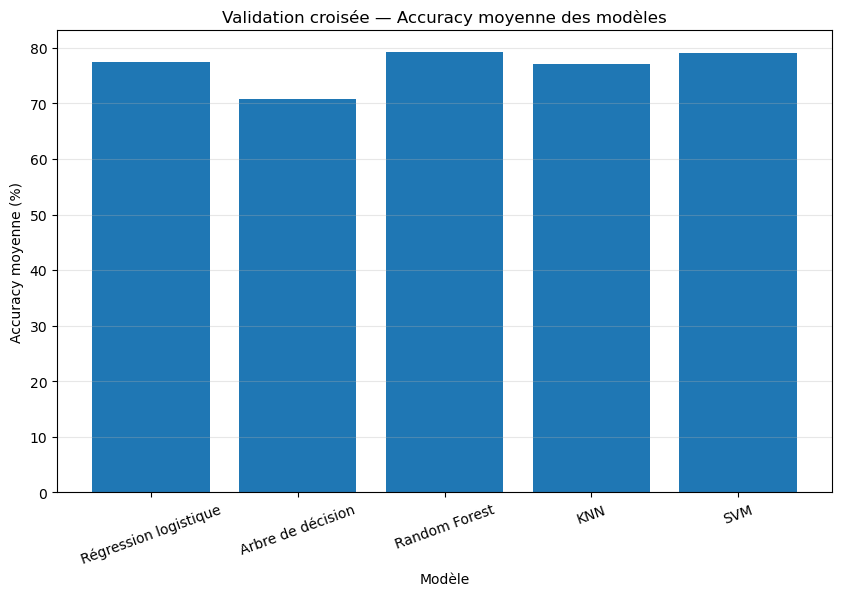

In [154]:
plt.figure(figsize=(10, 6))

plt.bar(
    resultats_cross_validation_pct["Modèle"],
    resultats_cross_validation_pct["Accuracy moyenne (%)"]
)

plt.ylabel("Accuracy moyenne (%)")
plt.xlabel("Modèle")
plt.title("Validation croisée — Accuracy moyenne des modèles")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [158]:
print("==============================================")
print("      VÉRIFICATION FINALE DU PROJET")
print("==============================================")

print("\n1. Données : OK")
print("   Nombre d'observations :", len(df))

print("\n2. Nettoyage : OK")
print("   Valeurs manquantes traitées")
print("   Doublons vérifiés")

print("\n3. Analyse statistique : OK")
print("   Statistiques descriptives")
print("   Corrélations")
print("   Chi-deux")
print("   ANOVA + Tukey")

print("\n4. ACP : OK")
print("   ACP réalisée")
print("   PC1 et PC2 disponibles")

print("\n5. Machine Learning : OK")
print("   5 modèles entraînés")

print("\n6. ROC / AUC multiclass : OK")
print("   Régression logistique : 0.8830")
print("   Arbre de décision     : 0.7426")
print("   Random Forest         : 0.8942")
print("   KNN                   : 0.8634")
print("   SVM                   : 0.8898")

print("\n7. Power BI : OK")
print("   Dashboard réalisé")

print("\n==============================================")
print("       PROJET TERMINÉ")
print("==============================================")

      VÉRIFICATION FINALE DU PROJET

1. Données : OK
   Nombre d'observations : 6646

2. Nettoyage : OK
   Valeurs manquantes traitées
   Doublons vérifiés

3. Analyse statistique : OK
   Statistiques descriptives
   Corrélations
   Chi-deux
   ANOVA + Tukey

4. ACP : OK
   ACP réalisée
   PC1 et PC2 disponibles

5. Machine Learning : OK
   5 modèles entraînés

6. ROC / AUC multiclass : OK
   Régression logistique : 0.8830
   Arbre de décision     : 0.7426
   Random Forest         : 0.8942
   KNN                   : 0.8634
   SVM                   : 0.8898

7. Power BI : OK
   Dashboard réalisé

       PROJET TERMINÉ


In [159]:
# Vérification des objets de résultats disponibles

print("Objets contenant 'result' :")
print([x for x in globals() if "result" in x.lower()])

print("\nObjets contenant 'auc' :")
print([x for x in globals() if "auc" in x.lower()])

print("\nObjets contenant 'accuracy' :")
print([x for x in globals() if "accuracy" in x.lower()])

Objets contenant 'result' :
['resultats_5_modeles', 'resultats_roc', 'resultats_finaux']

Objets contenant 'auc' :
['auc', 'calcul_auc_multiclass', 'auc_logistic', 'auc_tree', 'auc_forest', 'auc_knn', 'auc_svm', 'auc_comparaison', 'auc_macro']

Objets contenant 'accuracy' :
['accuracy_score', 'accuracy', 'accuracy_arbre', 'accuracy_logistique', 'accuracy_rf', 'accuracy_knn', 'accuracy_svm']


In [160]:
# ============================================================
# TABLEAU FINAL DE COMPARAISON DES 5 MODÈLES
# ============================================================

resultats_finaux

[]

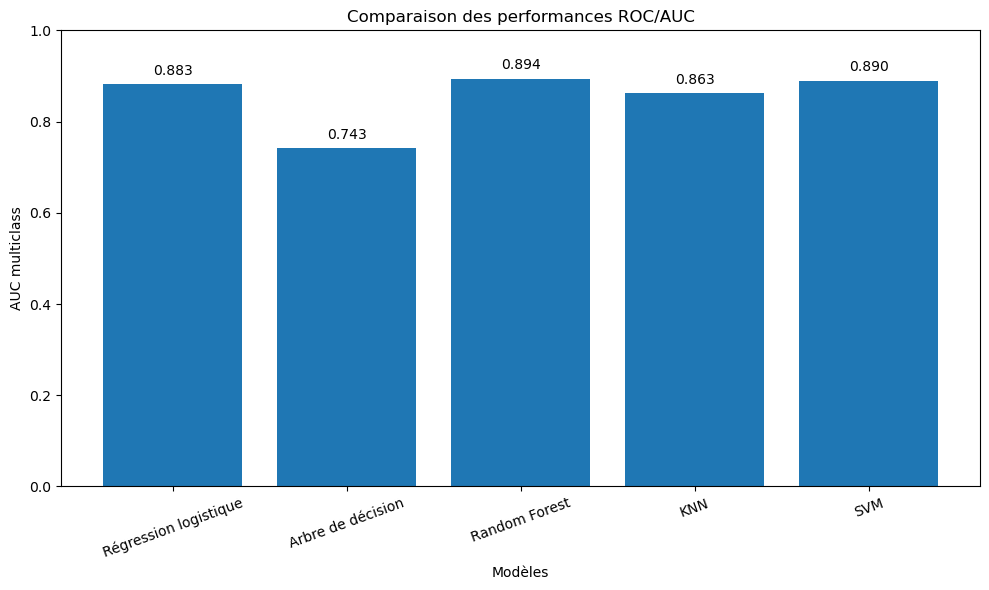

In [162]:
# ============================================================
# COMPARAISON DES AUC DES 5 MODÈLES
# ============================================================

import matplotlib.pyplot as plt

modeles = [
    "Régression logistique",
    "Arbre de décision",
    "Random Forest",
    "KNN",
    "SVM"
]

valeurs_auc = [
    auc_logistic,
    auc_tree,
    auc_forest,
    auc_knn,
    auc_svm
]

plt.figure(figsize=(10, 6))

barres = plt.bar(modeles, valeurs_auc)

plt.title("Comparaison des performances ROC/AUC")
plt.xlabel("Modèles")
plt.ylabel("AUC multiclass")
plt.ylim(0, 1)

# Affichage de la valeur au-dessus de chaque barre
for barre, valeur in zip(barres, valeurs_auc):
    plt.text(
        barre.get_x() + barre.get_width()/2,
        valeur + 0.02,
        f"{valeur:.3f}",
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Conclusion du Machine Learning

Dans cette étape, cinq modèles de classification ont été appliqués afin de prédire la catégorie de risque des clients : la régression logistique, l’arbre de décision, le Random Forest, le KNN et le SVM.

Les modèles ont été évalués à l’aide de plusieurs métriques, notamment l’Accuracy, la Precision, le Recall, le F1-score et l’AUC multiclass.

Les résultats ROC/AUC montrent des performances différentes selon les modèles. Les valeurs obtenues sont les suivantes :

- Régression logistique : AUC = 0.883
- Arbre de décision : AUC = 0.743
- Random Forest : AUC = 0.894
- KNN : AUC = 0.863
- SVM : AUC = 0.890

Globalement, les cinq modèles permettent de distinguer les différentes catégories de risque avec des niveaux de performance différents. L’analyse ROC/AUC complète ainsi les autres métriques d’évaluation et permet de comparer la capacité discriminante des modèles.

Il faut toutefois préciser que ces modèles correspondent aux versions initiales entraînées dans le projet et qu’aucune optimisation par GridSearchCV ou hyperparameter tuning n’a été retenue dans la version finale du projet.

Cette étape permet donc de compléter la partie Machine Learning et de préparer l’intégration des résultats dans le dashboard Power BI et dans le portfolio professionnel.

In [163]:
# ============================================================
# VÉRIFICATION FINALE DU PROJET MACHINE LEARNING
# ============================================================

print("===== RÉSULTATS AUC =====")

print(f"Régression logistique : {auc_logistic:.4f}")
print(f"Arbre de décision     : {auc_tree:.4f}")
print(f"Random Forest         : {auc_forest:.4f}")
print(f"KNN                   : {auc_knn:.4f}")
print(f"SVM                   : {auc_svm:.4f}")

print("\n===== OBJETS FINAUX =====")

print("resultats_5_modeles :", type(resultats_5_modeles))
print("resultats_roc       :", type(resultats_roc))
print("resultats_finaux    :", type(resultats_finaux))

===== RÉSULTATS AUC =====
Régression logistique : 0.8830
Arbre de décision     : 0.7426
Random Forest         : 0.8942
KNN                   : 0.8634
SVM                   : 0.8898

===== OBJETS FINAUX =====
resultats_5_modeles : <class 'pandas.core.frame.DataFrame'>
resultats_roc       : <class 'list'>
resultats_finaux    : <class 'list'>


## Conclusion générale du projet

Ce projet a permis de réaliser une analyse complète des données bancaires à partir d’un jeu de données contenant 6 646 observations clients.

L’analyse a commencé par l’extraction et la préparation des données avec SQL, suivies d’un nettoyage et d’une exploration des données avec Python et Pandas. Plusieurs analyses statistiques ont ensuite été réalisées afin de mieux comprendre les relations entre les caractéristiques financières et sociodémographiques des clients et leur catégorie de risque.

Les principales méthodes statistiques utilisées sont l’analyse des corrélations, le test du Chi², l’ANOVA, le test de Tukey et l’Analyse en Composantes Principales (ACP).

Dans la partie Machine Learning, cinq modèles de classification ont été développés : la Régression logistique, l’Arbre de décision, le Random Forest, le KNN et le SVM. Les modèles ont été évalués à l’aide de plusieurs métriques, notamment l’Accuracy, la Precision, le Recall, le F1-score et l’AUC multiclass.

Les résultats AUC obtenus sont les suivants :

* Régression logistique : 0,883
* Arbre de décision : 0,743
* Random Forest : 0,894
* KNN : 0,863
* SVM : 0,890

Enfin, les résultats de l’analyse ont été intégrés dans un dashboard Power BI permettant de présenter les principaux indicateurs, la structure du risque, les caractéristiques financières des clients, l’importance des variables et la comparaison des performances des modèles.

Ce projet constitue ainsi une démarche complète de Data Analytics appliquée au secteur bancaire, combinant SQL, Python, statistiques, Machine Learning et Business Intelligence.
